# 17. LaMa LPIPS Metrics

This notebook computes LPIPS perceptual-distance metrics for LaMa restorations across the standardized experiment manifests.

Truth-source requirements:

- enforce spatially valid LPIPS regions;
- compute full-image, content-region, and mask-bounding-box crop LPIPS;
- compare damaged input and restored output against the clean reference;
- compute restoration improvement as damaged LPIPS minus restored LPIPS;
- support canonical, damage-size, mask-robustness, and synthetic-degradation experiment manifests;
- validate outputs, row counts, region policy, and runtime/model versions.


## Batch 1 - Setup, Contract, and Input Discovery

This batch establishes the notebook contract before any expensive LPIPS computation runs.

It defines the input manifests, canonical outputs, runtime constants, and helper imports. Later batches will prepare the combined case table, run smoke tests, execute full LPIPS computation, summarize/rank cases, generate plots, and write the final validation/manifest files.


In [1]:
from __future__ import annotations

import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from restoration_eval.metrics_lpips import (
    DEFAULT_LPIPS_INPUT_SIZE,
    DEFAULT_LPIPS_NET,
    DEFAULT_MASK_BBOX_MARGIN,
    DEFAULT_MASK_BINARY_THRESHOLD,
    LPIPS_EVALUATION_REGIONS,
    LPIPS_METRIC_SCHEMA_VERSION,
    LPIPS_MODULE_NAME,
    compute_lpips_metrics_for_restorations,
    expected_lpips_region_counts_from_metadata,
    expected_lpips_rows_from_metadata,
    get_device,
    load_lpips_model,
    rank_lpips_cases,
    summarize_lpips_metrics,
    validate_lpips_metrics,
    validate_lpips_runtime_dependencies,
)

NOTEBOOK_NAME = "17_lama_lpips_metrics"
MODEL_NAME = "lama"
RUN_STARTED_AT_UTC = datetime.now(timezone.utc).isoformat()

print("Project root:", PROJECT_ROOT)
print("Notebook:", NOTEBOOK_NAME)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python:", platform.python_version())
print("LPIPS helper:", LPIPS_MODULE_NAME)
print("LPIPS schema:", LPIPS_METRIC_SCHEMA_VERSION)
print("LPIPS regions:", LPIPS_EVALUATION_REGIONS)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook: 17_lama_lpips_metrics
Run started: 2026-07-29T09:38:19.218105+00:00
Python: 3.12.6
LPIPS helper: restoration_eval.metrics_lpips
LPIPS schema: 2.0.0
LPIPS regions: ('full_image', 'content_region', 'mask_bbox_crop')


In [2]:
def project_relative_path(path: Path | str) -> str:
    path = Path(path)

    try:
        return str(path.resolve().relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def build_check(
    check_name: str,
    observed,
    expected,
    passed: bool,
    severity: str = "error",
) -> dict:
    return {
        "check": check_name,
        "observed": observed,
        "expected": expected,
        "passed": bool(passed),
        "severity": severity,
    }


def resolve_project_path(path_value) -> Path:
    if pd.isna(path_value):
        return Path("")

    candidate_path = Path(str(path_value))

    if candidate_path.is_absolute():
        return candidate_path

    return PROJECT_ROOT / candidate_path

In [3]:
PROCESSED_METADATA_DIR = PROJECT_ROOT / "data" / "processed" / "metadata"
RESTORED_METADATA_DIR = PROJECT_ROOT / "data" / "processed" / "restored" / MODEL_NAME

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / NOTEBOOK_NAME
MANIFESTS_DIR = PROJECT_ROOT / "outputs" / "manifests"
VALIDATION_DIR = PROJECT_ROOT / "outputs" / "validation"

for output_dir in [METRICS_DIR, FIGURES_DIR, MANIFESTS_DIR, VALIDATION_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

EXPECTED_LAMA_DATASETS = (
    "canonical",
    "damage_size",
    "mask_robustness",
    "synthetic_degradation",
)

LAMA_RESTORATION_MANIFEST_CANDIDATES = [
    PROCESSED_METADATA_DIR / "metadata_restored_lama.csv",
    RESTORED_METADATA_DIR / "metadata_restored_lama.csv",
]

PROCESSED_CLEAN_METADATA_PATH = PROCESSED_METADATA_DIR / "metadata_processed_clean.csv"

LPIPS_METRICS_OUTPUT_PATH = METRICS_DIR / "lpips_metrics_lama.csv"
LPIPS_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_lama.csv"
LPIPS_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_region_lama.csv"
LPIPS_GROUP_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_group_lama.csv"
LPIPS_RANKED_CASES_OUTPUT_PATH = METRICS_DIR / "lpips_ranked_cases_lama.csv"
LPIPS_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "lpips_validation_lama.csv"
LPIPS_STAGE_MANIFEST_JSON_PATH = MANIFESTS_DIR / "17_lama_lpips_metrics_manifest.json"

LPIPS_NET = DEFAULT_LPIPS_NET
LPIPS_INPUT_SIZE = DEFAULT_LPIPS_INPUT_SIZE
MASK_BBOX_MARGIN = DEFAULT_MASK_BBOX_MARGIN
MASK_BINARY_THRESHOLD = DEFAULT_MASK_BINARY_THRESHOLD

SMOKE_NONZERO_CASES = 2
SMOKE_ZERO_CONTROL_CASES = 1
RANK_TOP_N = 20

output_contract_df = pd.DataFrame(
    [
        {
            "artifact_key": "lpips_metrics",
            "path": LPIPS_METRICS_OUTPUT_PATH,
            "artifact_type": "csv",
            "required": True,
        },
        {
            "artifact_key": "lpips_summary",
            "path": LPIPS_SUMMARY_OUTPUT_PATH,
            "artifact_type": "csv",
            "required": True,
        },
        {
            "artifact_key": "lpips_summary_by_region",
            "path": LPIPS_REGION_SUMMARY_OUTPUT_PATH,
            "artifact_type": "csv",
            "required": True,
        },
        {
            "artifact_key": "lpips_summary_by_group",
            "path": LPIPS_GROUP_SUMMARY_OUTPUT_PATH,
            "artifact_type": "csv",
            "required": True,
        },
        {
            "artifact_key": "lpips_ranked_cases",
            "path": LPIPS_RANKED_CASES_OUTPUT_PATH,
            "artifact_type": "csv",
            "required": True,
        },
        {
            "artifact_key": "lpips_validation",
            "path": LPIPS_VALIDATION_OUTPUT_PATH,
            "artifact_type": "csv",
            "required": True,
        },
        {
            "artifact_key": "stage_manifest_json",
            "path": LPIPS_STAGE_MANIFEST_JSON_PATH,
            "artifact_type": "json",
            "required": True,
        },
    ]
)

output_contract_df["path_project_relative"] = output_contract_df["path"].map(
    project_relative_path
)

display(output_contract_df)

,artifact_key,path,artifact_type,required,path_project_relative
0,lpips_metrics,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_metrics_lama.csv
1,lpips_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_summary_lama.csv
2,lpips_summary_by_region,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_summary_by_region_lama.csv
3,lpips_summary_by_group,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_summary_by_group_lama.csv
4,lpips_ranked_cases,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_ranked_cases_lama.csv
5,lpips_validation,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\validation\lpips_validation_lama.csv
6,stage_manifest_json,D:\Masters\FH\Thesis\painting-restoration-eval...,json,True,outputs\manifests\17_lama_lpips_metrics_manife...


In [4]:
existing_lama_manifest_candidates = [
    candidate_path
    for candidate_path in LAMA_RESTORATION_MANIFEST_CANDIDATES
    if candidate_path.is_file()
]

LAMA_RESTORATION_MANIFEST_PATH = (
    existing_lama_manifest_candidates[0]
    if existing_lama_manifest_candidates
    else LAMA_RESTORATION_MANIFEST_CANDIDATES[0]
)

input_contract_df = pd.DataFrame(
    [
        {
            "input_key": "lama_restoration_manifest",
            "selected_path": LAMA_RESTORATION_MANIFEST_PATH,
            "selected_path_project_relative": project_relative_path(
                LAMA_RESTORATION_MANIFEST_PATH
            ),
            "candidate_count": len(LAMA_RESTORATION_MANIFEST_CANDIDATES),
            "existing_candidate_count": len(existing_lama_manifest_candidates),
            "exists": LAMA_RESTORATION_MANIFEST_PATH.is_file(),
        },
        {
            "input_key": "processed_clean_metadata",
            "selected_path": PROCESSED_CLEAN_METADATA_PATH,
            "selected_path_project_relative": project_relative_path(
                PROCESSED_CLEAN_METADATA_PATH
            ),
            "candidate_count": 1,
            "existing_candidate_count": int(PROCESSED_CLEAN_METADATA_PATH.is_file()),
            "exists": PROCESSED_CLEAN_METADATA_PATH.is_file(),
        },
    ]
)

display(input_contract_df)

if not LAMA_RESTORATION_MANIFEST_PATH.is_file():
    raise RuntimeError(
        "Consolidated LaMa restoration manifest is missing: "
        f"{project_relative_path(LAMA_RESTORATION_MANIFEST_PATH)}"
    )

if not PROCESSED_CLEAN_METADATA_PATH.is_file():
    raise RuntimeError(
        "Processed clean metadata is missing: "
        f"{project_relative_path(PROCESSED_CLEAN_METADATA_PATH)}"
    )

,input_key,selected_path,selected_path_project_relative,candidate_count,existing_candidate_count,exists
0,lama_restoration_manifest,D:\Masters\FH\Thesis\painting-restoration-eval...,data\processed\metadata\metadata_restored_lama...,2,1,True
1,processed_clean_metadata,D:\Masters\FH\Thesis\painting-restoration-eval...,data\processed\metadata\metadata_processed_cle...,1,1,True


In [5]:
lama_manifest_probe_df = pd.read_csv(LAMA_RESTORATION_MANIFEST_PATH)

required_probe_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_probe_columns = [
    column
    for column in required_probe_columns
    if column not in lama_manifest_probe_df.columns
]

if missing_probe_columns:
    raise RuntimeError(
        f"LaMa restoration manifest missing required columns: {missing_probe_columns}"
    )

lama_manifest_dataset_counts_df = (
    lama_manifest_probe_df["dataset_name"]
    .fillna("<missing>")
    .value_counts()
    .rename_axis("dataset_name")
    .reset_index(name="row_count")
    .sort_values("dataset_name")
)

expected_dataset_coverage_df = pd.DataFrame(
    [
        {
            "dataset_name": dataset_name,
            "row_count": int(
                lama_manifest_probe_df["dataset_name"].eq(dataset_name).sum()
            ),
            "available": bool(
                lama_manifest_probe_df["dataset_name"].eq(dataset_name).any()
            ),
        }
        for dataset_name in EXPECTED_LAMA_DATASETS
    ]
)

display(lama_manifest_dataset_counts_df)
display(expected_dataset_coverage_df)

missing_expected_datasets = expected_dataset_coverage_df.loc[
    ~expected_dataset_coverage_df["available"],
    "dataset_name",
].tolist()

unexpected_model_names = sorted(
    set(lama_manifest_probe_df["model_name"].dropna().astype(str).unique()) - {MODEL_NAME}
)

batch_1_validation_df = pd.DataFrame(
    [
        build_check(
            "lama_restoration_manifest_available",
            LAMA_RESTORATION_MANIFEST_PATH.is_file(),
            True,
            LAMA_RESTORATION_MANIFEST_PATH.is_file(),
        ),
        build_check(
            "processed_clean_metadata_available",
            PROCESSED_CLEAN_METADATA_PATH.is_file(),
            True,
            PROCESSED_CLEAN_METADATA_PATH.is_file(),
        ),
        build_check(
            "lama_manifest_nonempty",
            len(lama_manifest_probe_df),
            "> 0",
            len(lama_manifest_probe_df) > 0,
        ),
        build_check(
            "lama_manifest_required_columns",
            missing_probe_columns,
            [],
            not missing_probe_columns,
        ),
        build_check(
            "all_expected_lama_datasets_available",
            missing_expected_datasets,
            [],
            not missing_expected_datasets,
        ),
        build_check(
            "only_lama_model_rows",
            unexpected_model_names,
            [],
            not unexpected_model_names,
        ),
    ]
)

display(batch_1_validation_df)

if not batch_1_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 1 input contract validation failed.")

print("Batch 1 complete.")
print("Selected LaMa manifest:", project_relative_path(LAMA_RESTORATION_MANIFEST_PATH))
print("Manifest rows:", len(lama_manifest_probe_df))
print("Ready for Batch 2: load and standardize LaMa LPIPS cases.")

,dataset_name,row_count
0,canonical,250
3,damage_size,35
1,mask_robustness,75
2,synthetic_degradation,50


,dataset_name,row_count,available
0,canonical,250,True
1,damage_size,35,True
2,mask_robustness,75,True
3,synthetic_degradation,50,True


,check,observed,expected,passed,severity
0,lama_restoration_manifest_available,True,True,True,error
1,processed_clean_metadata_available,True,True,True,error
2,lama_manifest_nonempty,410,> 0,True,error
3,lama_manifest_required_columns,[],[],True,error
4,all_expected_lama_datasets_available,[],[],True,error
5,only_lama_model_rows,[],[],True,error


Batch 1 complete.
Selected LaMa manifest: data\processed\metadata\metadata_restored_lama.csv
Manifest rows: 410
Ready for Batch 2: load and standardize LaMa LPIPS cases.


In [6]:
lama_restored_raw_df = pd.read_csv(LAMA_RESTORATION_MANIFEST_PATH)
processed_clean_df = pd.read_csv(PROCESSED_CLEAN_METADATA_PATH)

print("LaMa restoration manifest:", project_relative_path(LAMA_RESTORATION_MANIFEST_PATH))
print("LaMa restoration shape:", lama_restored_raw_df.shape)
print("Processed clean metadata:", project_relative_path(PROCESSED_CLEAN_METADATA_PATH))
print("Processed clean metadata shape:", processed_clean_df.shape)

display(lama_restored_raw_df.head())
display(processed_clean_df.head())

LaMa restoration manifest: data\processed\metadata\metadata_restored_lama.csv
LaMa restoration shape: (410, 218)
Processed clean metadata: data\processed\metadata\metadata_processed_clean.csv
Processed clean metadata shape: (50, 47)


,restoration_case_id,model_name,iopaint_model_name,iopaint_package_version,lama_model_version,restoration_method,inference_mode,restoration_generator_name,restoration_generator_version,execution_device,...,degraded_path,effect_mask_sha256,degraded_sha256,effect_mask_file_size_bytes,degraded_file_size_bytes,lama_mask_area_pixels,lama_staged_input_path,lama_staged_mask_path,lama_staged_output_path,device
0,lama__canonical__canonical__p001_loss_large,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,69018,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
1,lama__canonical__canonical__p001_loss_small,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,18239,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
2,lama__canonical__canonical__p001_mixed_damage,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,45733,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
3,lama__canonical__canonical__p001_scratch_thin,lama,lama,NaN,iopaint_lama,iopaint_lama,model_inference,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,12058,outputs/tmp/lama_batch_full/input/canonical__p...,outputs/tmp/lama_batch_full/mask/canonical__p0...,outputs/tmp/lama_batch_full/output/canonical__...,cuda
4,lama__canonical__canonical__p001_zero_control,lama,lama,NaN,iopaint_lama,zero_control_copy,copied_zero_control,restoration_eval.restoration_lama,2.0.0,cuda,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,none


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


In [7]:
clean_lookup_required_columns = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_clean_lookup_columns = [
    column
    for column in clean_lookup_required_columns
    if column not in processed_clean_df.columns
]

if missing_clean_lookup_columns:
    raise RuntimeError(
        f"Processed clean metadata missing required columns: {missing_clean_lookup_columns}"
    )

optional_clean_lookup_columns = [
    column
    for column in ["artist", "style", "style_or_period"]
    if column in processed_clean_df.columns
]

clean_metadata_lookup_df = (
    processed_clean_df[clean_lookup_required_columns + optional_clean_lookup_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

lama_lpips_cases_df = lama_restored_raw_df.copy()

columns_refreshed_from_clean = [
    "category",
    "title",
    "artist",
    "style",
    "style_or_period",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

lama_lpips_cases_df = lama_lpips_cases_df.drop(
    columns=[
        column
        for column in columns_refreshed_from_clean
        if column in lama_lpips_cases_df.columns
    ],
    errors="ignore",
)

lama_lpips_cases_df = lama_lpips_cases_df.merge(
    clean_metadata_lookup_df,
    on="painting_id",
    how="left",
    validate="many_to_one",
)

metadata_enrichment_required_columns = [
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

metadata_enrichment_missing_df = (
    lama_lpips_cases_df[metadata_enrichment_required_columns]
    .isna()
    .sum()
    .reset_index()
)

metadata_enrichment_missing_df.columns = ["column", "missing_count"]

display(metadata_enrichment_missing_df)

if metadata_enrichment_missing_df["missing_count"].sum() > 0:
    display(
        lama_lpips_cases_df.loc[
            lama_lpips_cases_df[metadata_enrichment_required_columns].isna().any(axis=1),
            ["dataset_name", "case_id", "painting_id"] + metadata_enrichment_required_columns,
        ].head(30)
    )
    raise RuntimeError("LaMa LPIPS metadata enrichment failed.")

print("Enriched LaMa LPIPS cases:", lama_lpips_cases_df.shape)

,column,missing_count
0,category,0
1,title,0
2,content_x_min,0
3,content_y_min,0
4,content_x_max,0
5,content_y_max,0


Enriched LaMa LPIPS cases: (410, 219)


In [8]:
required_manifest_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_manifest_columns = [
    column
    for column in required_manifest_columns
    if column not in lama_lpips_cases_df.columns
]

if missing_manifest_columns:
    raise RuntimeError(
        f"LaMa restoration manifest missing required columns: {missing_manifest_columns}"
    )

for column in ["dataset_name", "case_id", "painting_id", "model_name"]:
    lama_lpips_cases_df[column] = lama_lpips_cases_df[column].fillna("").astype(str)

if "status" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["status"] = "ok"

non_ok_cases_df = lama_lpips_cases_df.loc[
    lama_lpips_cases_df["status"].astype(str).ne("ok")
].copy()

if not non_ok_cases_df.empty:
    display(
        non_ok_cases_df[
            [
                column
                for column in [
                    "dataset_name",
                    "case_id",
                    "painting_id",
                    "model_name",
                    "status",
                    "issue",
                ]
                if column in non_ok_cases_df.columns
            ]
        ].head(30)
    )
    raise RuntimeError("LaMa restoration manifest contains non-ok rows.")

if "restoration_case_id" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["restoration_case_id"] = (
        lama_lpips_cases_df["dataset_name"] + "__" + lama_lpips_cases_df["case_id"]
    )

if "source_case_id" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["source_case_id"] = lama_lpips_cases_df["case_id"]

if "source_case_id_original" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["source_case_id_original"] = lama_lpips_cases_df["source_case_id"]

if "mask_type" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["mask_type"] = "unknown"

if "mask_id" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["mask_id"] = lama_lpips_cases_df["mask_type"]

if "metric_mask_type" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["metric_mask_type"] = lama_lpips_cases_df["mask_type"]

if "metric_mask_id" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["metric_mask_id"] = lama_lpips_cases_df["mask_id"]

if "metric_case_id" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["metric_case_id"] = lama_lpips_cases_df["restoration_case_id"]

if "metric_applicability" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["metric_applicability"] = "primary"

if "is_zero_control" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["is_zero_control"] = (
        lama_lpips_cases_df["mask_type"]
        .astype(str)
        .str.contains("zero", case=False, na=False)
    )

if "mask_area_pixels" not in lama_lpips_cases_df.columns:
    lama_lpips_cases_df["mask_area_pixels"] = np.nan

string_fill_columns = [
    "restoration_case_id",
    "source_case_id",
    "source_case_id_original",
    "metric_case_id",
    "mask_type",
    "mask_id",
    "metric_mask_type",
    "metric_mask_id",
    "metric_applicability",
]

for column in string_fill_columns:
    lama_lpips_cases_df[column] = lama_lpips_cases_df[column].fillna("").astype(str)

print("Dataset counts:")
display(
    lama_lpips_cases_df["dataset_name"]
    .value_counts()
    .rename_axis("dataset_name")
    .reset_index(name="case_count")
)

print("Mask type counts by dataset:")
display(
    lama_lpips_cases_df
    .groupby(["dataset_name", "mask_type"], dropna=False)
    .size()
    .reset_index(name="case_count")
    .sort_values(["dataset_name", "mask_type"])
)

Dataset counts:


,dataset_name,case_count
0,canonical,250
1,mask_robustness,75
2,synthetic_degradation,50
3,damage_size,35


Mask type counts by dataset:


,dataset_name,mask_type,case_count
0,canonical,loss_large,50
1,canonical,loss_small,50
2,canonical,mixed_damage,50
3,canonical,scratch_thin,50
4,canonical,zero_control,50
5,damage_size,,35
6,mask_robustness,,75
7,synthetic_degradation,,50


In [9]:
lama_lpips_cases_abs_df = lama_lpips_cases_df.copy()

path_columns = ["clean_path", "damaged_path", "restored_path", "mask_path"]

for path_column in path_columns:
    lama_lpips_cases_abs_df[path_column] = lama_lpips_cases_abs_df[path_column].map(
        resolve_project_path
    )
    lama_lpips_cases_abs_df[f"{path_column}_project_relative"] = (
        lama_lpips_cases_abs_df[path_column].map(project_relative_path)
    )

missing_path_records = []

for path_column in path_columns:
    missing_rows_df = lama_lpips_cases_abs_df.loc[
        ~lama_lpips_cases_abs_df[path_column].map(lambda value: Path(value).is_file()),
        ["dataset_name", "case_id", "painting_id", "restoration_case_id", path_column],
    ].copy()

    for _, missing_row in missing_rows_df.head(50).iterrows():
        missing_path_records.append(
            {
                "path_column": path_column,
                "dataset_name": missing_row["dataset_name"],
                "case_id": missing_row["case_id"],
                "painting_id": missing_row["painting_id"],
                "restoration_case_id": missing_row["restoration_case_id"],
                "path": str(missing_row[path_column]),
                "path_project_relative": project_relative_path(missing_row[path_column]),
            }
        )

missing_paths_df = pd.DataFrame(missing_path_records)

if not missing_paths_df.empty:
    display(missing_paths_df)
    raise RuntimeError("Some LaMa LPIPS input image/mask files are missing.")

content_box_columns = [
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

for content_column in content_box_columns:
    lama_lpips_cases_abs_df[content_column] = pd.to_numeric(
        lama_lpips_cases_abs_df[content_column],
        errors="coerce",
    )

invalid_content_boxes_df = lama_lpips_cases_abs_df.loc[
    lama_lpips_cases_abs_df[content_box_columns].isna().any(axis=1)
    | lama_lpips_cases_abs_df["content_x_max"].le(lama_lpips_cases_abs_df["content_x_min"])
    | lama_lpips_cases_abs_df["content_y_max"].le(lama_lpips_cases_abs_df["content_y_min"])
].copy()

duplicate_metric_case_ids = int(lama_lpips_cases_abs_df["metric_case_id"].duplicated().sum())
duplicate_restoration_case_ids = int(
    lama_lpips_cases_abs_df["restoration_case_id"].duplicated().sum()
)

selected_dataset_counts = lama_lpips_cases_abs_df["dataset_name"].value_counts().to_dict()

missing_expected_datasets = [
    dataset_name
    for dataset_name in EXPECTED_LAMA_DATASETS
    if int(selected_dataset_counts.get(dataset_name, 0)) == 0
]

case_table_validation_df = pd.DataFrame(
    [
        build_check(
            "case_table_nonempty",
            len(lama_lpips_cases_abs_df),
            "> 0",
            len(lama_lpips_cases_abs_df) > 0,
        ),
        build_check(
            "all_expected_datasets_present",
            missing_expected_datasets,
            [],
            not missing_expected_datasets,
        ),
        build_check(
            "all_model_names_lama",
            sorted(lama_lpips_cases_abs_df["model_name"].unique().tolist()),
            [MODEL_NAME],
            set(lama_lpips_cases_abs_df["model_name"].unique()) == {MODEL_NAME},
        ),
        build_check(
            "unique_restoration_case_ids",
            duplicate_restoration_case_ids,
            0,
            duplicate_restoration_case_ids == 0,
        ),
        build_check(
            "unique_metric_case_ids",
            duplicate_metric_case_ids,
            0,
            duplicate_metric_case_ids == 0,
        ),
        build_check(
            "all_input_paths_exist",
            len(missing_paths_df),
            0,
            missing_paths_df.empty,
        ),
        build_check(
            "valid_content_boxes",
            len(invalid_content_boxes_df),
            0,
            invalid_content_boxes_df.empty,
        ),
    ]
)

display(case_table_validation_df)

if not invalid_content_boxes_df.empty:
    display(
        invalid_content_boxes_df[
            [
                "dataset_name",
                "case_id",
                "painting_id",
                "content_x_min",
                "content_y_min",
                "content_x_max",
                "content_y_max",
            ]
        ].head(30)
    )

if not case_table_validation_df["passed"].astype(bool).all():
    raise RuntimeError("LaMa LPIPS case table validation failed.")

display(
    lama_lpips_cases_abs_df[
        [
            "dataset_name",
            "case_id",
            "restoration_case_id",
            "metric_case_id",
            "painting_id",
            "category",
            "mask_type",
            "model_name",
            "clean_path_project_relative",
            "damaged_path_project_relative",
            "restored_path_project_relative",
            "mask_path_project_relative",
        ]
    ].head()
)

,check,observed,expected,passed,severity
0,case_table_nonempty,410,> 0,True,error
1,all_expected_datasets_present,[],[],True,error
2,all_model_names_lama,[lama],[lama],True,error
3,unique_restoration_case_ids,0,0,True,error
4,unique_metric_case_ids,0,0,True,error
5,all_input_paths_exist,0,0,True,error
6,valid_content_boxes,0,0,True,error


,dataset_name,case_id,restoration_case_id,metric_case_id,painting_id,category,mask_type,model_name,clean_path_project_relative,damaged_path_project_relative,restored_path_project_relative,mask_path_project_relative
0,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001,portrait_figure,loss_large,lama,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_large_damaged.png,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_loss_large_mask.png
1,canonical,canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,p001,portrait_figure,loss_small,lama,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_small_damaged.png,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_loss_small_mask.png
2,canonical,canonical__p001_mixed_damage,lama__canonical__canonical__p001_mixed_damage,lama__canonical__canonical__p001_mixed_damage,p001,portrait_figure,mixed_damage,lama,data\processed\clean\p001_clean.png,data\processed\masked\p001_mixed_damage_damage...,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_mixed_damage_mask.png
3,canonical,canonical__p001_scratch_thin,lama__canonical__canonical__p001_scratch_thin,lama__canonical__canonical__p001_scratch_thin,p001,portrait_figure,scratch_thin,lama,data\processed\clean\p001_clean.png,data\processed\masked\p001_scratch_thin_damage...,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_scratch_thin_mask.png
4,canonical,canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,p001,portrait_figure,zero_control,lama,data\processed\clean\p001_clean.png,data\processed\masked\p001_zero_control_damage...,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_zero_control_mask.png


In [10]:
lpips_expected_region_counts = expected_lpips_region_counts_from_metadata(
    lama_lpips_cases_abs_df
)

lpips_expected_total_rows = expected_lpips_rows_from_metadata(
    lama_lpips_cases_abs_df
)

lpips_expected_contract_df = pd.DataFrame(
    [
        {
            "evaluation_region": evaluation_region,
            "expected_rows": int(expected_rows),
        }
        for evaluation_region, expected_rows in lpips_expected_region_counts.items()
    ]
)

lpips_expected_contract_df.loc[len(lpips_expected_contract_df)] = {
    "evaluation_region": "__total__",
    "expected_rows": int(lpips_expected_total_rows),
}

display(lpips_expected_contract_df)

dataset_contract_df = (
    lama_lpips_cases_abs_df
    .groupby("dataset_name", dropna=False)
    .agg(
        case_count=("restoration_case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
        zero_control_cases=("is_zero_control", "sum"),
    )
    .reset_index()
    .sort_values("dataset_name")
)

display(dataset_contract_df)

batch_2_completion_checks_df = pd.DataFrame(
    [
        build_check(
            "expected_lpips_total_rows_gt_cases",
            int(lpips_expected_total_rows),
            f"> {len(lama_lpips_cases_abs_df)}",
            int(lpips_expected_total_rows) > len(lama_lpips_cases_abs_df),
        ),
        build_check(
            "expected_regions_match_policy",
            sorted(lpips_expected_region_counts.keys()),
            sorted(LPIPS_EVALUATION_REGIONS),
            sorted(lpips_expected_region_counts.keys()) == sorted(LPIPS_EVALUATION_REGIONS),
        ),
        build_check(
            "mask_bbox_rows_do_not_exceed_cases",
            int(lpips_expected_region_counts.get("mask_bbox_crop", 0)),
            f"<= {len(lama_lpips_cases_abs_df)}",
            int(lpips_expected_region_counts.get("mask_bbox_crop", 0)) <= len(lama_lpips_cases_abs_df),
        ),
    ]
)

display(batch_2_completion_checks_df)

if not batch_2_completion_checks_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 2 LPIPS expected-row contract failed.")

print("Batch 2 complete.")
print("Standardized LaMa LPIPS cases:", len(lama_lpips_cases_abs_df))
print("Expected LPIPS rows:", lpips_expected_total_rows)

,evaluation_region,expected_rows
0,full_image,410
1,content_region,410
2,mask_bbox_crop,355
3,__total__,1175


,dataset_name,case_count,painting_count,zero_control_cases
0,canonical,250,50,50
1,damage_size,35,5,0
2,mask_robustness,75,5,0
3,synthetic_degradation,50,5,0


,check,observed,expected,passed,severity
0,expected_lpips_total_rows_gt_cases,1175,> 410,True,error
1,expected_regions_match_policy,"[content_region, full_image, mask_bbox_crop]","[content_region, full_image, mask_bbox_crop]",True,error
2,mask_bbox_rows_do_not_exceed_cases,355,<= 410,True,error


Batch 2 complete.
Standardized LaMa LPIPS cases: 410
Expected LPIPS rows: 1175


In [11]:
LPIPS_TARGET_SIZE = 768
LPIPS_SMOKE_OUTPUT_PATH = VALIDATION_DIR / "lpips_smoke_lama.csv"
LPIPS_SMOKE_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "lpips_smoke_validation_lama.csv"

lpips_dependency_check_df = validate_lpips_runtime_dependencies()
display(lpips_dependency_check_df)

if not lpips_dependency_check_df["passed"].astype(bool).all():
    raise RuntimeError("LPIPS runtime dependencies are missing.")

lpips_device = get_device(prefer_cuda=True)

print("Selected LPIPS device:", lpips_device)
print("LPIPS net:", LPIPS_NET)
print("LPIPS target image size:", LPIPS_TARGET_SIZE)
print("LPIPS input crop size:", LPIPS_INPUT_SIZE)

lpips_model_load_start = perf_counter()

lpips_model = load_lpips_model(
    net=LPIPS_NET,
    device=lpips_device,
)

lpips_model_load_seconds = perf_counter() - lpips_model_load_start

print(f"LPIPS model loaded in {lpips_model_load_seconds:.2f} seconds.")

,component,module,version,required,installed,passed
0,torch,torch,2.5.1+cu121,True,True,True
1,lpips,lpips,0.1.4,True,True,True
2,Pillow,PIL,11.0.0,True,True,True


Selected LPIPS device: cuda
LPIPS net: alex
LPIPS target image size: 768
LPIPS input crop size: 256
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\lpips\weights\v0.1\alex.pth


C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mo

LPIPS model loaded in 9.29 seconds.


In [12]:
nonzero_smoke_candidates_df = (
    lama_lpips_cases_abs_df.loc[
        ~lama_lpips_cases_abs_df["is_zero_control"].astype(bool)
    ]
    .sort_values(["dataset_name", "painting_id", "case_id"], kind="stable")
    .head(SMOKE_NONZERO_CASES)
    .copy()
)

zero_control_smoke_candidates_df = (
    lama_lpips_cases_abs_df.loc[
        lama_lpips_cases_abs_df["is_zero_control"].astype(bool)
    ]
    .sort_values(["dataset_name", "painting_id", "case_id"], kind="stable")
    .head(SMOKE_ZERO_CONTROL_CASES)
    .copy()
)

lpips_smoke_cases_df = (
    pd.concat(
        [nonzero_smoke_candidates_df, zero_control_smoke_candidates_df],
        ignore_index=True,
    )
    .sort_values(["dataset_name", "painting_id", "case_id"], kind="stable")
    .reset_index(drop=True)
)

smoke_selection_checks_df = pd.DataFrame(
    [
        build_check(
            "smoke_cases_nonempty",
            len(lpips_smoke_cases_df),
            f"{SMOKE_NONZERO_CASES + SMOKE_ZERO_CONTROL_CASES}",
            len(lpips_smoke_cases_df) == SMOKE_NONZERO_CASES + SMOKE_ZERO_CONTROL_CASES,
        ),
        build_check(
            "smoke_nonzero_case_count",
            int((~lpips_smoke_cases_df["is_zero_control"].astype(bool)).sum()),
            SMOKE_NONZERO_CASES,
            int((~lpips_smoke_cases_df["is_zero_control"].astype(bool)).sum()) == SMOKE_NONZERO_CASES,
        ),
        build_check(
            "smoke_zero_control_case_count",
            int(lpips_smoke_cases_df["is_zero_control"].astype(bool).sum()),
            SMOKE_ZERO_CONTROL_CASES,
            int(lpips_smoke_cases_df["is_zero_control"].astype(bool).sum()) == SMOKE_ZERO_CONTROL_CASES,
        ),
        build_check(
            "smoke_unique_metric_case_ids",
            int(lpips_smoke_cases_df["metric_case_id"].duplicated().sum()),
            0,
            int(lpips_smoke_cases_df["metric_case_id"].duplicated().sum()) == 0,
        ),
    ]
)

display(smoke_selection_checks_df)

display(
    lpips_smoke_cases_df[
        [
            "dataset_name",
            "case_id",
            "metric_case_id",
            "painting_id",
            "mask_type",
            "is_zero_control",
            "clean_path_project_relative",
            "damaged_path_project_relative",
            "restored_path_project_relative",
            "mask_path_project_relative",
        ]
    ]
)

if not smoke_selection_checks_df["passed"].astype(bool).all():
    raise RuntimeError("LPIPS smoke-test case selection failed.")

,check,observed,expected,passed,severity
0,smoke_cases_nonempty,3,3,True,error
1,smoke_nonzero_case_count,2,2,True,error
2,smoke_zero_control_case_count,1,1,True,error
3,smoke_unique_metric_case_ids,0,0,True,error


,dataset_name,case_id,metric_case_id,painting_id,mask_type,is_zero_control,clean_path_project_relative,damaged_path_project_relative,restored_path_project_relative,mask_path_project_relative
0,canonical,canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,p001,loss_large,False,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_large_damaged.png,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_loss_large_mask.png
1,canonical,canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,p001,loss_small,False,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_small_damaged.png,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_loss_small_mask.png
2,canonical,canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,p001,zero_control,True,data\processed\clean\p001_clean.png,data\processed\masked\p001_zero_control_damage...,data\processed\restored\lama\canonical\canonic...,data\processed\masks\p001_zero_control_mask.png


In [13]:
lpips_smoke_expected_region_counts = expected_lpips_region_counts_from_metadata(
    lpips_smoke_cases_df
)

lpips_smoke_expected_rows = expected_lpips_rows_from_metadata(
    lpips_smoke_cases_df
)

print("Smoke expected region counts:", lpips_smoke_expected_region_counts)
print("Smoke expected total rows:", lpips_smoke_expected_rows)

lpips_smoke_start = perf_counter()

lpips_smoke_df = compute_lpips_metrics_for_restorations(
    restoration_metadata=lpips_smoke_cases_df,
    lpips_model=lpips_model,
    device=lpips_device,
    lpips_net=LPIPS_NET,
    target_size=LPIPS_TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    lpips_input_size=LPIPS_INPUT_SIZE,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
    progress_every=1,
)

lpips_smoke_runtime_seconds = perf_counter() - lpips_smoke_start

print(f"Smoke LPIPS runtime: {lpips_smoke_runtime_seconds:.2f} seconds")

display(lpips_smoke_df)

Smoke expected region counts: {'full_image': 3, 'content_region': 3, 'mask_bbox_crop': 2}
Smoke expected total rows: 8
Starting LPIPS metric computation
  Cases: 3
  Target size: (768, 768)
  LPIPS net: alex
  LPIPS input size: 256
  Device: cuda
Computing LPIPS case 1/3 (canonical__p001_loss_large) | elapsed 0.00s
Computing LPIPS case 2/3 (canonical__p001_loss_small) | elapsed 1.38s
Computing LPIPS case 3/3 (canonical__p001_zero_control) | elapsed 1.83s
LPIPS metric computation complete
  Runtime: 2.21 seconds
  Output rows: 8
  Region counts:
evaluation_region
full_image        3
content_region    3
mask_bbox_crop    2
  Status counts:
status
ok    8
Smoke LPIPS runtime: 2.22 seconds


,lpips_row_id,lpips_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,...,lpips_implementation_name,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,lpips_package_version,status,issue
0,lama__canonical__canonical__p001_loss_large__f...,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
1,lama__canonical__canonical__p001_loss_large__c...,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
2,lama__canonical__canonical__p001_loss_large__m...,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
3,lama__canonical__canonical__p001_loss_small__f...,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
4,lama__canonical__canonical__p001_loss_small__c...,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
5,lama__canonical__canonical__p001_loss_small__m...,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
6,lama__canonical__canonical__p001_zero_control_...,lama__canonical__canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,canonical__p001_zero_control,p001_zero_control,canonical__p001_zero_control,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
7,lama__canonical__canonical__p001_zero_control_...,lama__canonical__canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,lama__canonical__canonical__p001_zero_control,canonical__p001_zero_control,p001_zero_control,canonical__p001_zero_control,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,


In [14]:
lpips_smoke_validation_df = validate_lpips_metrics(
    lpips_smoke_df,
    expected_rows=lpips_smoke_expected_rows,
    expected_region_counts=lpips_smoke_expected_region_counts,
)

display(lpips_smoke_validation_df)

lpips_smoke_df.to_csv(LPIPS_SMOKE_OUTPUT_PATH, index=False)
lpips_smoke_validation_df.to_csv(LPIPS_SMOKE_VALIDATION_OUTPUT_PATH, index=False)

print("Smoke metrics saved:", project_relative_path(LPIPS_SMOKE_OUTPUT_PATH))
print("Smoke validation saved:", project_relative_path(LPIPS_SMOKE_VALIDATION_OUTPUT_PATH))

if not lpips_smoke_validation_df["passed"].astype(bool).all():
    error_preview_columns = [
        "dataset_name",
        "case_id",
        "metric_case_id",
        "evaluation_region",
        "status",
        "issue",
    ]

    display(
        lpips_smoke_df[
            [column for column in error_preview_columns if column in lpips_smoke_df.columns]
        ]
    )

    raise RuntimeError("LPIPS smoke validation failed.")

print("Batch 3 complete.")
print("LPIPS model is loaded and smoke test passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 8, found 8."
2,no_error_rows,True,Error rows: 0.
3,unique_lpips_keys,True,Rows participating in duplicate keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,region_policy,True,All LPIPS rows use image-like evaluation regions.
6,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


Smoke metrics saved: outputs\validation\lpips_smoke_lama.csv
Smoke validation saved: outputs\validation\lpips_smoke_validation_lama.csv
Batch 3 complete.
LPIPS model is loaded and smoke test passed.


In [15]:
FORCE_RECOMPUTE_FULL_LPIPS = True
FULL_LPIPS_PROGRESS_EVERY = 10

full_run_contract_df = pd.DataFrame(
    [
        build_check(
            "case_table_available",
            len(lama_lpips_cases_abs_df),
            "> 0",
            len(lama_lpips_cases_abs_df) > 0,
        ),
        build_check(
            "expected_rows_available",
            int(lpips_expected_total_rows),
            "> 0",
            int(lpips_expected_total_rows) > 0,
        ),
        build_check(
            "lpips_model_loaded",
            lpips_model is not None,
            True,
            lpips_model is not None,
        ),
        build_check(
            "lpips_device_available",
            str(lpips_device),
            "non-empty",
            bool(str(lpips_device)),
        ),
    ]
)

display(full_run_contract_df)

if not full_run_contract_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 4 cannot start because the full-run contract failed.")

print("Full LPIPS cases:", len(lama_lpips_cases_abs_df))
print("Expected LPIPS rows:", lpips_expected_total_rows)
print("Expected region counts:", lpips_expected_region_counts)
print("Force recompute:", FORCE_RECOMPUTE_FULL_LPIPS)

,check,observed,expected,passed,severity
0,case_table_available,410,> 0,True,error
1,expected_rows_available,1175,> 0,True,error
2,lpips_model_loaded,True,True,True,error
3,lpips_device_available,cuda,non-empty,True,error


Full LPIPS cases: 410
Expected LPIPS rows: 1175
Expected region counts: {'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}
Force recompute: True


In [16]:
if LPIPS_METRICS_OUTPUT_PATH.is_file() and not FORCE_RECOMPUTE_FULL_LPIPS:
    print("Loading existing full LPIPS metrics:")
    print(project_relative_path(LPIPS_METRICS_OUTPUT_PATH))

    lpips_metrics_lama_df = pd.read_csv(LPIPS_METRICS_OUTPUT_PATH)
    full_lpips_runtime_seconds = np.nan
else:
    full_lpips_start = perf_counter()

    lpips_metrics_lama_df = compute_lpips_metrics_for_restorations(
        restoration_metadata=lama_lpips_cases_abs_df,
        lpips_model=lpips_model,
        device=lpips_device,
        lpips_net=LPIPS_NET,
        target_size=LPIPS_TARGET_SIZE,
        mask_bbox_margin=MASK_BBOX_MARGIN,
        lpips_input_size=LPIPS_INPUT_SIZE,
        mask_binary_threshold=MASK_BINARY_THRESHOLD,
        progress_every=FULL_LPIPS_PROGRESS_EVERY,
    )

    full_lpips_runtime_seconds = perf_counter() - full_lpips_start

print("Full LPIPS dataframe shape:", lpips_metrics_lama_df.shape)
print(f"Full LPIPS runtime seconds: {full_lpips_runtime_seconds}")

display(lpips_metrics_lama_df.head())
display(
    lpips_metrics_lama_df["evaluation_region"]
    .value_counts()
    .rename_axis("evaluation_region")
    .reset_index(name="row_count")
)

Starting LPIPS metric computation
  Cases: 410
  Target size: (768, 768)
  LPIPS net: alex
  LPIPS input size: 256
  Device: cuda
Computing LPIPS case 1/410 (canonical__p001_loss_large) | elapsed 0.07s
Computing LPIPS case 10/410 (canonical__p002_zero_control) | elapsed 3.38s
Computing LPIPS case 20/410 (canonical__p004_zero_control) | elapsed 7.19s
Computing LPIPS case 30/410 (canonical__p006_zero_control) | elapsed 10.56s
Computing LPIPS case 40/410 (canonical__p008_zero_control) | elapsed 14.20s
Computing LPIPS case 50/410 (canonical__p010_zero_control) | elapsed 18.20s
Computing LPIPS case 60/410 (canonical__p012_zero_control) | elapsed 21.66s
Computing LPIPS case 70/410 (canonical__p014_zero_control) | elapsed 25.12s
Computing LPIPS case 80/410 (canonical__p016_zero_control) | elapsed 28.88s
Computing LPIPS case 90/410 (canonical__p018_zero_control) | elapsed 32.28s
Computing LPIPS case 100/410 (canonical__p020_zero_control) | elapsed 35.96s
Computing LPIPS case 110/410 (canonical

,lpips_row_id,lpips_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,...,lpips_implementation_name,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,lpips_package_version,status,issue
0,lama__canonical__canonical__p001_loss_large__f...,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
1,lama__canonical__canonical__p001_loss_large__c...,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
2,lama__canonical__canonical__p001_loss_large__m...,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
3,lama__canonical__canonical__p001_loss_small__f...,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,
4,lama__canonical__canonical__p001_loss_small__c...,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,...,restoration_eval.metrics_lpips,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.1.4,ok,


,evaluation_region,row_count
0,full_image,410
1,content_region,410
2,mask_bbox_crop,355


In [17]:
lpips_validation_lama_df = validate_lpips_metrics(
    lpips_metrics_lama_df,
    expected_rows=lpips_expected_total_rows,
    expected_region_counts=lpips_expected_region_counts,
)

display(lpips_validation_lama_df)

status_counts_df = (
    lpips_metrics_lama_df["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="row_count")
)

display(status_counts_df)

if not lpips_validation_lama_df["passed"].astype(bool).all():
    preview_columns = [
        "dataset_name",
        "case_id",
        "lpips_case_id",
        "restoration_case_id",
        "painting_id",
        "evaluation_region",
        "status",
        "issue",
    ]

    display(
        lpips_metrics_lama_df.loc[
            lpips_metrics_lama_df["status"].astype(str).ne("ok"),
            [column for column in preview_columns if column in lpips_metrics_lama_df.columns],
        ].head(50)
    )

    raise RuntimeError("Full LaMa LPIPS validation failed.")

print("Full LPIPS validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 1175, found 1175."
2,no_error_rows,True,Error rows: 0.
3,unique_lpips_keys,True,Rows participating in duplicate keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,region_policy,True,All LPIPS rows use image-like evaluation regions.
6,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


,status,row_count
0,ok,1175


Full LPIPS validation passed.


In [18]:
lpips_summary_lama_df = summarize_lpips_metrics(
    lpips_metrics_lama_df,
    group_columns=["model_name"],
)

lpips_region_summary_lama_df = summarize_lpips_metrics(
    lpips_metrics_lama_df,
    group_columns=["model_name", "evaluation_region"],
)

lpips_group_summary_lama_df = summarize_lpips_metrics(
    lpips_metrics_lama_df,
    group_columns=["dataset_name", "mask_type", "evaluation_region"],
)

strongest_lpips_cases_df, weakest_lpips_cases_df = rank_lpips_cases(
    lpips_metrics_lama_df,
    evaluation_region="mask_bbox_crop",
    top_n=RANK_TOP_N,
)

strongest_lpips_cases_df = strongest_lpips_cases_df.copy()
weakest_lpips_cases_df = weakest_lpips_cases_df.copy()

strongest_lpips_cases_df["rank_group"] = "strongest_improvement"
weakest_lpips_cases_df["rank_group"] = "weakest_improvement"

lpips_ranked_cases_lama_df = pd.concat(
    [strongest_lpips_cases_df, weakest_lpips_cases_df],
    ignore_index=True,
)

display(lpips_summary_lama_df)
display(lpips_region_summary_lama_df)
display(lpips_group_summary_lama_df.head(30))
display(
    lpips_ranked_cases_lama_df[
        [
            column
            for column in [
                "rank_group",
                "dataset_name",
                "case_id",
                "lpips_case_id",
                "painting_id",
                "mask_type",
                "evaluation_region",
                "damaged_lpips",
                "restored_lpips",
                "lpips_improvement",
            ]
            if column in lpips_ranked_cases_lama_df.columns
        ]
    ]
)

,model_name,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
0,lama,1175,410,0.192625,0.009952,0.173675,0.219143,0.041418,0.177724,0.791489,509184.0


,model_name,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
0,lama,full_image,410,410,0.154168,0.006471,0.124298,0.159003,0.020266,0.138737,0.756098,589824.0
1,lama,content_region,410,410,0.187275,0.008834,0.148268,0.186502,0.026616,0.159886,0.756098,440064.0
2,lama,mask_bbox_crop,355,355,0.294946,0.019286,0.261275,0.326297,0.082943,0.243354,0.873239,376996.0


,dataset_name,mask_type,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
0,canonical,loss_large,full_image,50,50,0.160147,0.049922,0.113187,0.167426,0.048077,0.119349,1.0,589824.0
1,canonical,loss_large,content_region,50,50,0.196355,0.064041,0.137390,0.207005,0.062582,0.144423,1.0,446208.0
2,canonical,loss_large,mask_bbox_crop,50,50,0.560892,0.222329,0.329846,0.553725,0.213810,0.339915,1.0,109561.0
3,canonical,loss_small,full_image,50,50,0.138883,0.005977,0.129848,0.150301,0.006418,0.143882,1.0,589824.0
4,canonical,loss_small,content_region,50,50,0.162714,0.007695,0.154840,0.179524,0.008858,0.170666,1.0,446208.0
5,canonical,loss_small,mask_bbox_crop,50,50,0.198520,0.010257,0.183368,0.195694,0.011834,0.183860,1.0,360000.0
6,canonical,mixed_damage,full_image,50,50,0.330681,0.019307,0.311908,0.323036,0.018766,0.304270,1.0,589824.0
7,canonical,mixed_damage,content_region,50,50,0.383650,0.025560,0.353851,0.370493,0.024578,0.345914,1.0,446208.0
8,canonical,mixed_damage,mask_bbox_crop,50,50,0.333898,0.020656,0.316820,0.327529,0.019484,0.308045,1.0,589824.0
9,canonical,scratch_thin,full_image,50,50,0.266257,0.001236,0.265683,0.260849,0.001798,0.259051,1.0,589824.0


,rank_group,dataset_name,case_id,lpips_case_id,painting_id,mask_type,evaluation_region,damaged_lpips,restored_lpips,lpips_improvement
0,strongest_improvement,mask_robustness,mask_robustness__p001__loss_large__variant_05,lama__mask_robustness__mask_robustness__p001__...,p001,,mask_bbox_crop,0.698316,0.096510,0.601806
1,strongest_improvement,canonical,canonical__p011_loss_large,lama__canonical__canonical__p011_loss_large,p011,loss_large,mask_bbox_crop,0.688783,0.127980,0.560803
2,strongest_improvement,damage_size,damage_size__p026__loss_large__size_02pct,lama__damage_size__damage_size__p026__loss_lar...,p026,,mask_bbox_crop,0.655318,0.096308,0.559010
3,strongest_improvement,damage_size,damage_size__p001__loss_large__size_02pct,lama__damage_size__damage_size__p001__loss_lar...,p001,,mask_bbox_crop,0.609372,0.075608,0.533764
4,strongest_improvement,canonical,canonical__p044_loss_large,lama__canonical__canonical__p044_loss_large,p044,loss_large,mask_bbox_crop,0.766593,0.235461,0.531132
5,strongest_improvement,damage_size,damage_size__p001__loss_large__size_04pct,lama__damage_size__damage_size__p001__loss_lar...,p001,,mask_bbox_crop,0.634536,0.108442,0.526094
6,strongest_improvement,canonical,canonical__p001_scratch_thin,lama__canonical__canonical__p001_scratch_thin,p001,scratch_thin,mask_bbox_crop,0.524122,0.001695,0.522427
7,strongest_improvement,damage_size,damage_size__p026__loss_large__size_04pct,lama__damage_size__damage_size__p026__loss_lar...,p026,,mask_bbox_crop,0.653558,0.131901,0.521657
8,strongest_improvement,damage_size,damage_size__p026__loss_large__size_06pct,lama__damage_size__damage_size__p026__loss_lar...,p026,,mask_bbox_crop,0.662642,0.144449,0.518193
9,strongest_improvement,damage_size,damage_size__p026__loss_large__size_08pct,lama__damage_size__damage_size__p026__loss_lar...,p026,,mask_bbox_crop,0.664267,0.147762,0.516505


In [19]:
def json_safe(value):
    if isinstance(value, Path):
        return project_relative_path(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


lpips_metrics_lama_df.to_csv(LPIPS_METRICS_OUTPUT_PATH, index=False)
lpips_summary_lama_df.to_csv(LPIPS_SUMMARY_OUTPUT_PATH, index=False)
lpips_region_summary_lama_df.to_csv(LPIPS_REGION_SUMMARY_OUTPUT_PATH, index=False)
lpips_group_summary_lama_df.to_csv(LPIPS_GROUP_SUMMARY_OUTPUT_PATH, index=False)
lpips_ranked_cases_lama_df.to_csv(LPIPS_RANKED_CASES_OUTPUT_PATH, index=False)
lpips_validation_lama_df.to_csv(LPIPS_VALIDATION_OUTPUT_PATH, index=False)

batch_4_manifest = {
    "notebook_name": NOTEBOOK_NAME,
    "model_name": MODEL_NAME,
    "run_started_at_utc": RUN_STARTED_AT_UTC,
    "batch_4_completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "lpips": {
        "net": LPIPS_NET,
        "device": str(lpips_device),
        "target_size": LPIPS_TARGET_SIZE,
        "input_size": LPIPS_INPUT_SIZE,
        "mask_bbox_margin": MASK_BBOX_MARGIN,
        "mask_binary_threshold": MASK_BINARY_THRESHOLD,
        "schema_version": LPIPS_METRIC_SCHEMA_VERSION,
        "runtime_seconds": full_lpips_runtime_seconds,
    },
    "inputs": {
        "lama_restoration_manifest": project_relative_path(LAMA_RESTORATION_MANIFEST_PATH),
        "processed_clean_metadata": project_relative_path(PROCESSED_CLEAN_METADATA_PATH),
        "case_count": int(len(lama_lpips_cases_abs_df)),
        "expected_lpips_rows": int(lpips_expected_total_rows),
        "expected_region_counts": {
            key: int(value)
            for key, value in lpips_expected_region_counts.items()
        },
    },
    "outputs": {
        "lpips_metrics": project_relative_path(LPIPS_METRICS_OUTPUT_PATH),
        "lpips_summary": project_relative_path(LPIPS_SUMMARY_OUTPUT_PATH),
        "lpips_summary_by_region": project_relative_path(LPIPS_REGION_SUMMARY_OUTPUT_PATH),
        "lpips_summary_by_group": project_relative_path(LPIPS_GROUP_SUMMARY_OUTPUT_PATH),
        "lpips_ranked_cases": project_relative_path(LPIPS_RANKED_CASES_OUTPUT_PATH),
        "lpips_validation": project_relative_path(LPIPS_VALIDATION_OUTPUT_PATH),
    },
    "validation": lpips_validation_lama_df.to_dict(orient="records"),
}

with open(LPIPS_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(batch_4_manifest, manifest_file, indent=2, default=json_safe)

saved_outputs_df = output_contract_df.copy()
saved_outputs_df["exists"] = saved_outputs_df["path"].map(lambda path: Path(path).is_file())
saved_outputs_df["size_bytes"] = saved_outputs_df["path"].map(
    lambda path: Path(path).stat().st_size if Path(path).is_file() else 0
)

display(saved_outputs_df)

if not saved_outputs_df["exists"].astype(bool).all():
    raise RuntimeError("Some Batch 4 output artifacts were not saved.")

print("Batch 4 complete.")
print("Full LaMa LPIPS metrics saved:", project_relative_path(LPIPS_METRICS_OUTPUT_PATH))
print("Rows:", len(lpips_metrics_lama_df))

,artifact_key,path,artifact_type,required,path_project_relative,exists,size_bytes
0,lpips_metrics,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_metrics_lama.csv,True,856763
1,lpips_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_summary_lama.csv,True,283
2,lpips_summary_by_region,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_summary_by_region_lama.csv,True,513
3,lpips_summary_by_group,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_summary_by_group_lama.csv,True,2635
4,lpips_ranked_cases,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\metrics\lpips_ranked_cases_lama.csv,True,33671
5,lpips_validation,D:\Masters\FH\Thesis\painting-restoration-eval...,csv,True,outputs\validation\lpips_validation_lama.csv,True,443
6,stage_manifest_json,D:\Masters\FH\Thesis\painting-restoration-eval...,json,True,outputs\manifests\17_lama_lpips_metrics_manife...,True,2245


Batch 4 complete.
Full LaMa LPIPS metrics saved: outputs\metrics\lpips_metrics_lama.csv
Rows: 1175


In [20]:
LPIPS_COMPACT_METRICS_OUTPUT_PATH = METRICS_DIR / "lpips_metrics_lama_compact.csv"
LPIPS_DATASET_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_dataset_region_lama.csv"
LPIPS_MASK_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_mask_region_lama.csv"
LPIPS_CATEGORY_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_category_region_lama.csv"
LPIPS_ZERO_CONTROL_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_zero_control_lama.csv"
LPIPS_RANKED_BY_REGION_OUTPUT_PATH = METRICS_DIR / "lpips_ranked_cases_by_region_lama.csv"
LPIPS_BATCH5_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "lpips_batch5_validation_lama.csv"

def existing_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    return [column for column in columns if column in df.columns]


def round_float_columns(df: pd.DataFrame, decimals: int = 6) -> pd.DataFrame:
    rounded_df = df.copy()

    float_columns = rounded_df.select_dtypes(include=["float", "float64", "float32"]).columns
    rounded_df[float_columns] = rounded_df[float_columns].round(decimals)

    return rounded_df

In [22]:
if not LPIPS_METRICS_OUTPUT_PATH.is_file():
    raise RuntimeError(
        "Full LPIPS metrics file is missing. Run Batch 4 first: "
        f"{project_relative_path(LPIPS_METRICS_OUTPUT_PATH)}"
    )

lpips_metrics_batch5_df = pd.read_csv(LPIPS_METRICS_OUTPUT_PATH)

lpips_batch5_contract_validation_df = validate_lpips_metrics(
    lpips_metrics_batch5_df,
    expected_rows=lpips_expected_total_rows,
    expected_region_counts=lpips_expected_region_counts,
)

numeric_metric_columns = ["damaged_lpips", "restored_lpips", "lpips_improvement"]
ok_metrics_df = lpips_metrics_batch5_df.loc[
    lpips_metrics_batch5_df["status"].astype(str).eq("ok")
].copy()

finite_metric_failures = 0

for metric_column in numeric_metric_columns:
    finite_metric_failures += int(
        (~np.isfinite(pd.to_numeric(ok_metrics_df[metric_column], errors="coerce"))).sum()
    )

actual_region_counts = (
    lpips_metrics_batch5_df["evaluation_region"]
    .value_counts()
    .rename_axis("evaluation_region")
    .reset_index(name="actual_rows")
)

expected_region_counts_df = pd.DataFrame(
    [
        {
            "evaluation_region": region,
            "expected_rows": int(expected_rows),
        }
        for region, expected_rows in lpips_expected_region_counts.items()
    ]
)

region_count_audit_df = expected_region_counts_df.merge(
    actual_region_counts,
    on="evaluation_region",
    how="outer",
).fillna(0)

region_count_audit_df["expected_rows"] = region_count_audit_df["expected_rows"].astype(int)
region_count_audit_df["actual_rows"] = region_count_audit_df["actual_rows"].astype(int)
region_count_audit_df["matches"] = (
    region_count_audit_df["expected_rows"].eq(region_count_audit_df["actual_rows"])
)

batch5_extra_validation_df = pd.DataFrame(
    [
        build_check(
            "raw_metrics_file_exists",
            LPIPS_METRICS_OUTPUT_PATH.is_file(),
            True,
            LPIPS_METRICS_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "raw_metrics_row_count",
            len(lpips_metrics_batch5_df),
            int(lpips_expected_total_rows),
            len(lpips_metrics_batch5_df) == int(lpips_expected_total_rows),
        ),
        build_check(
            "all_region_counts_match",
            int(region_count_audit_df["matches"].sum()),
            len(region_count_audit_df),
            bool(region_count_audit_df["matches"].all()),
        ),
        build_check(
            "no_nonfinite_ok_metric_values",
            int(finite_metric_failures),
            0,
            int(finite_metric_failures) == 0,
        ),
    ]
)

display(lpips_batch5_contract_validation_df)
display(region_count_audit_df)
display(batch5_extra_validation_df)

if (
    not lpips_batch5_contract_validation_df["passed"].astype(bool).all()
    or not batch5_extra_validation_df["passed"].astype(bool).all()
):
    raise RuntimeError("Batch 5 LPIPS revalidation failed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 1175, found 1175."
2,no_error_rows,True,Error rows: 0.
3,unique_lpips_keys,True,Rows participating in duplicate keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,region_policy,True,All LPIPS rows use image-like evaluation regions.
6,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


,evaluation_region,expected_rows,actual_rows,matches
0,content_region,410,410,True
1,full_image,410,410,True
2,mask_bbox_crop,355,355,True


,check,observed,expected,passed,severity
0,raw_metrics_file_exists,True,True,True,error
1,raw_metrics_row_count,1175,1175,True,error
2,all_region_counts_match,3,3,True,error
3,no_nonfinite_ok_metric_values,0,0,True,error


In [23]:
lpips_dataset_region_summary_df = summarize_lpips_metrics(
    lpips_metrics_batch5_df,
    group_columns=["dataset_name", "evaluation_region"],
).sort_values(["dataset_name", "evaluation_region"], kind="stable")

lpips_mask_region_summary_df = summarize_lpips_metrics(
    lpips_metrics_batch5_df,
    group_columns=["dataset_name", "mask_type", "evaluation_region"],
).sort_values(["dataset_name", "mask_type", "evaluation_region"], kind="stable")

lpips_category_region_summary_df = summarize_lpips_metrics(
    lpips_metrics_batch5_df,
    group_columns=["category", "evaluation_region"],
).sort_values(["evaluation_region", "median_lpips_improvement"], ascending=[True, False], kind="stable")

lpips_zero_control_summary_df = summarize_lpips_metrics(
    lpips_metrics_batch5_df,
    group_columns=["is_zero_control", "evaluation_region"],
).sort_values(["is_zero_control", "evaluation_region"], kind="stable")

display(lpips_dataset_region_summary_df)
display(lpips_mask_region_summary_df.head(40))
display(lpips_category_region_summary_df.head(40))
display(lpips_zero_control_summary_df)

,dataset_name,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
1,canonical,content_region,250,250,0.199778,0.007340,0.173013,0.210377,0.019680,0.190697,0.8,446208.0
0,canonical,full_image,250,250,0.172776,0.004772,0.147089,0.180322,0.015012,0.165311,0.8,589824.0
2,canonical,mask_bbox_crop,200,200,0.307371,0.014797,0.268348,0.336893,0.061798,0.275095,1.0,474038.5
4,damage_size,content_region,35,35,0.158148,0.032889,0.114342,0.171084,0.043498,0.127586,1.0,433152.0
3,damage_size,full_image,35,35,0.120067,0.024210,0.093615,0.138317,0.032240,0.106078,1.0,589824.0
5,damage_size,mask_bbox_crop,35,35,0.634861,0.218724,0.404265,0.625275,0.212885,0.412390,1.0,71289.0
7,mask_robustness,content_region,75,75,0.221993,0.008312,0.201040,0.230284,0.023462,0.206822,1.0,433152.0
6,mask_robustness,full_image,75,75,0.176548,0.005844,0.167265,0.196569,0.018124,0.178445,1.0,589824.0
8,mask_robustness,mask_bbox_crop,75,75,0.311139,0.009830,0.264808,0.343840,0.069721,0.274119,1.0,351649.0
10,synthetic_degradation,content_region,50,50,0.003703,0.010805,-0.003124,0.012246,0.054210,-0.041963,0.0,433152.0


,dataset_name,mask_type,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
1,canonical,loss_large,content_region,50,50,0.196355,0.064041,0.137390,0.207005,0.062582,0.144423,1.0,446208.0
0,canonical,loss_large,full_image,50,50,0.160147,0.049922,0.113187,0.167426,0.048077,0.119349,1.0,589824.0
2,canonical,loss_large,mask_bbox_crop,50,50,0.560892,0.222329,0.329846,0.553725,0.213810,0.339915,1.0,109561.0
4,canonical,loss_small,content_region,50,50,0.162714,0.007695,0.154840,0.179524,0.008858,0.170666,1.0,446208.0
3,canonical,loss_small,full_image,50,50,0.138883,0.005977,0.129848,0.150301,0.006418,0.143882,1.0,589824.0
5,canonical,loss_small,mask_bbox_crop,50,50,0.198520,0.010257,0.183368,0.195694,0.011834,0.183860,1.0,360000.0
7,canonical,mixed_damage,content_region,50,50,0.383650,0.025560,0.353851,0.370493,0.024578,0.345914,1.0,446208.0
6,canonical,mixed_damage,full_image,50,50,0.330681,0.019307,0.311908,0.323036,0.018766,0.304270,1.0,589824.0
8,canonical,mixed_damage,mask_bbox_crop,50,50,0.333898,0.020656,0.316820,0.327529,0.019484,0.308045,1.0,589824.0
10,canonical,scratch_thin,content_region,50,50,0.295204,0.001342,0.289784,0.294863,0.002382,0.292480,1.0,446208.0


,category,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
1,portrait_figure,content_region,82,82,0.234163,0.007797,0.208935,0.236831,0.031126,0.205705,0.756098,509184.0
7,architecture_structured,content_region,82,82,0.220478,0.009896,0.196027,0.209218,0.023843,0.185376,0.756098,406272.0
4,landscape_natural,content_region,82,82,0.202475,0.013222,0.164613,0.192193,0.025038,0.167156,0.756098,389376.0
13,high_texture_brushwork,content_region,82,82,0.169649,0.008750,0.136386,0.180051,0.027448,0.152603,0.756098,469248.0
10,abstraction_surrealism,content_region,82,82,0.120263,0.006508,0.091714,0.114216,0.025627,0.088589,0.756098,433152.0
0,portrait_figure,full_image,82,82,0.216454,0.005546,0.186052,0.213899,0.026376,0.187523,0.756098,589824.0
6,architecture_structured,full_image,82,82,0.184031,0.006703,0.160202,0.179212,0.017618,0.161594,0.756098,589824.0
3,landscape_natural,full_image,82,82,0.154241,0.007787,0.132139,0.147359,0.015867,0.131492,0.756098,589824.0
12,high_texture_brushwork,full_image,82,82,0.137319,0.006541,0.112728,0.153946,0.021683,0.132264,0.756098,589824.0
9,abstraction_surrealism,full_image,82,82,0.103776,0.004137,0.079922,0.100598,0.019785,0.080813,0.756098,589824.0


,is_zero_control,evaluation_region,rows,cases,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate,median_region_pixel_count
1,False,content_region,360,360,0.202242,0.012898,0.172066,0.212405,0.030313,0.182092,0.861111,438528.0
0,False,full_image,360,360,0.169817,0.008694,0.141527,0.181087,0.023080,0.158006,0.861111,589824.0
2,False,mask_bbox_crop,355,355,0.294946,0.019286,0.261275,0.326297,0.082943,0.243354,0.873239,376996.0
4,True,content_region,50,50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,446208.0
3,True,full_image,50,50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,589824.0


In [24]:
ranking_frames = []

available_lpips_regions = [
    region
    for region in LPIPS_EVALUATION_REGIONS
    if region in set(lpips_metrics_batch5_df["evaluation_region"].dropna().astype(str))
]

for evaluation_region in available_lpips_regions:
    strongest_region_df, weakest_region_df = rank_lpips_cases(
        lpips_metrics_batch5_df,
        evaluation_region=evaluation_region,
        top_n=RANK_TOP_N,
    )

    strongest_region_df = strongest_region_df.copy()
    weakest_region_df = weakest_region_df.copy()

    strongest_region_df["rank_group"] = "strongest_improvement"
    weakest_region_df["rank_group"] = "weakest_improvement"

    strongest_region_df["rank_position"] = np.arange(1, len(strongest_region_df) + 1)
    weakest_region_df["rank_position"] = np.arange(1, len(weakest_region_df) + 1)

    ranking_frames.extend([strongest_region_df, weakest_region_df])

lpips_ranked_by_region_df = pd.concat(ranking_frames, ignore_index=True)

ranking_compact_columns = existing_columns(
    lpips_ranked_by_region_df,
    [
        "rank_group",
        "rank_position",
        "evaluation_region",
        "dataset_name",
        "case_id",
        "lpips_case_id",
        "restoration_case_id",
        "painting_id",
        "category",
        "title",
        "artist",
        "style",
        "mask_type",
        "is_zero_control",
        "region_pixel_count",
        "damaged_lpips",
        "restored_lpips",
        "lpips_improvement",
    ],
)

lpips_ranked_by_region_compact_df = round_float_columns(
    lpips_ranked_by_region_df[ranking_compact_columns],
    decimals=6,
)

display(lpips_ranked_by_region_compact_df)

,rank_group,rank_position,evaluation_region,dataset_name,case_id,lpips_case_id,restoration_case_id,painting_id,category,title,artist,style,mask_type,is_zero_control,region_pixel_count,damaged_lpips,restored_lpips,lpips_improvement
0,strongest_improvement,1,full_image,canonical,canonical__p001_scratch_thin,lama__canonical__canonical__p001_scratch_thin,lama__canonical__canonical__p001_scratch_thin,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,scratch_thin,False,589824,0.524122,0.001695,0.522427
1,strongest_improvement,2,full_image,mask_robustness,mask_robustness__p001__scratch_thin__variant_05,lama__mask_robustness__mask_robustness__p001__...,lama__mask_robustness__mask_robustness__p001__...,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,NaN,False,589824,0.498262,0.002608,0.495653
2,strongest_improvement,3,full_image,canonical,canonical__p001_mixed_damage,lama__canonical__canonical__p001_mixed_damage,lama__canonical__canonical__p001_mixed_damage,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,mixed_damage,False,589824,0.504022,0.024102,0.479921
3,strongest_improvement,4,full_image,canonical,canonical__p006_mixed_damage,lama__canonical__canonical__p006_mixed_damage,lama__canonical__canonical__p006_mixed_damage,p006,portrait_figure,Boy with a Sword,Édouard Manet,Realism / early modern French painting,mixed_damage,False,589824,0.494518,0.016288,0.478230
4,strongest_improvement,5,full_image,mask_robustness,mask_robustness__p001__scratch_thin__variant_04,lama__mask_robustness__mask_robustness__p001__...,lama__mask_robustness__mask_robustness__p001__...,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,NaN,False,589824,0.465010,0.005844,0.459166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,weakest_improvement,16,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p001__water_stain__severe,lama__synthetic_degradation__synthetic_degrada...,lama__synthetic_degradation__synthetic_degrada...,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,NaN,False,14161,0.042552,0.134495,-0.091943
116,weakest_improvement,17,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p043__water_stain__severe,lama__synthetic_degradation__synthetic_degrada...,lama__synthetic_degradation__synthetic_degrada...,p043,high_texture_brushwork,The Card Players,Paul Cézanne,Post-Impressionism,NaN,False,98596,0.021947,0.111696,-0.089750
117,weakest_improvement,18,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p018__water_stain__severe,lama__synthetic_degradation__synthetic_degrada...,lama__synthetic_degradation__synthetic_degrada...,p018,landscape_natural,Classical Landscape with Figures,Henri Mauperché,NaN,NaN,False,76729,0.014002,0.073608,-0.059606
118,weakest_improvement,19,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p043__water_stain_dirt_...,lama__synthetic_degradation__synthetic_degrada...,lama__synthetic_degradation__synthetic_degrada...,p043,high_texture_brushwork,The Card Players,Paul Cézanne,Post-Impressionism,NaN,False,204304,0.010046,0.055397,-0.045351


In [25]:
compact_metric_columns = existing_columns(
    lpips_metrics_batch5_df,
    [
        "lpips_row_id",
        "lpips_case_id",
        "restoration_case_id",
        "source_case_id",
        "case_id",
        "dataset_name",
        "painting_id",
        "category",
        "title",
        "artist",
        "style",
        "model_name",
        "mask_type",
        "mask_id",
        "is_zero_control",
        "evaluation_region",
        "region_pixel_count",
        "mask_area_pixels",
        "damaged_lpips",
        "restored_lpips",
        "lpips_improvement",
        "lpips_net",
        "lpips_input_size",
        "status",
        "issue",
    ],
)

lpips_metrics_compact_df = round_float_columns(
    lpips_metrics_batch5_df[compact_metric_columns]
    .sort_values(["dataset_name", "painting_id", "case_id", "evaluation_region"], kind="stable")
    .reset_index(drop=True),
    decimals=6,
)

compact_summary_tables = {
    LPIPS_COMPACT_METRICS_OUTPUT_PATH: lpips_metrics_compact_df,
    LPIPS_DATASET_REGION_SUMMARY_OUTPUT_PATH: round_float_columns(lpips_dataset_region_summary_df),
    LPIPS_MASK_REGION_SUMMARY_OUTPUT_PATH: round_float_columns(lpips_mask_region_summary_df),
    LPIPS_CATEGORY_REGION_SUMMARY_OUTPUT_PATH: round_float_columns(lpips_category_region_summary_df),
    LPIPS_ZERO_CONTROL_SUMMARY_OUTPUT_PATH: round_float_columns(lpips_zero_control_summary_df),
    LPIPS_RANKED_BY_REGION_OUTPUT_PATH: lpips_ranked_by_region_compact_df,
}

for output_path, output_df in compact_summary_tables.items():
    output_df.to_csv(output_path, index=False)

batch5_validation_combined_df = pd.concat(
    [
        lpips_batch5_contract_validation_df.assign(validation_source="helper_contract"),
        batch5_extra_validation_df.assign(validation_source="batch5_extra"),
    ],
    ignore_index=True,
)

batch5_validation_combined_df.to_csv(LPIPS_BATCH5_VALIDATION_OUTPUT_PATH, index=False)

compact_save_audit_df = pd.DataFrame(
    [
        {
            "artifact": output_path.stem,
            "path": output_path,
            "path_project_relative": project_relative_path(output_path),
            "exists": output_path.is_file(),
            "size_bytes": output_path.stat().st_size if output_path.is_file() else 0,
            "rows": len(output_df),
            "columns": len(output_df.columns),
        }
        for output_path, output_df in compact_summary_tables.items()
    ]
)

compact_save_audit_df.loc[len(compact_save_audit_df)] = {
    "artifact": LPIPS_BATCH5_VALIDATION_OUTPUT_PATH.stem,
    "path": LPIPS_BATCH5_VALIDATION_OUTPUT_PATH,
    "path_project_relative": project_relative_path(LPIPS_BATCH5_VALIDATION_OUTPUT_PATH),
    "exists": LPIPS_BATCH5_VALIDATION_OUTPUT_PATH.is_file(),
    "size_bytes": (
        LPIPS_BATCH5_VALIDATION_OUTPUT_PATH.stat().st_size
        if LPIPS_BATCH5_VALIDATION_OUTPUT_PATH.is_file()
        else 0
    ),
    "rows": len(batch5_validation_combined_df),
    "columns": len(batch5_validation_combined_df.columns),
}

display(compact_save_audit_df)

if not compact_save_audit_df["exists"].astype(bool).all():
    raise RuntimeError("Some Batch 5 compact outputs were not saved.")

,artifact,path,path_project_relative,exists,size_bytes,rows,columns
0,lpips_metrics_lama_compact,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_metrics_lama_compact.csv,True,526051,1175,25
1,lpips_summary_by_dataset_region_lama,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_by_dataset_regio...,True,1449,12,12
2,lpips_summary_by_mask_region_lama,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_by_mask_region_l...,True,2635,23,13
3,lpips_summary_by_category_region_lama,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_by_category_regi...,True,1909,15,12
4,lpips_summary_zero_control_lama,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_zero_control_lam...,True,644,5,12
5,lpips_ranked_cases_by_region_lama,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_ranked_cases_by_region_l...,True,43432,120,18
6,lpips_batch5_validation_lama,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\validation\lpips_batch5_validation_lam...,True,853,11,7


In [26]:
if LPIPS_STAGE_MANIFEST_JSON_PATH.is_file():
    with open(LPIPS_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
        lpips_stage_manifest = json.load(manifest_file)
else:
    lpips_stage_manifest = {}

lpips_stage_manifest["batch_5"] = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "validation_summaries_rankings_compact_csv_saves",
    "inputs": {
        "raw_lpips_metrics": project_relative_path(LPIPS_METRICS_OUTPUT_PATH),
        "raw_rows": int(len(lpips_metrics_batch5_df)),
        "expected_rows": int(lpips_expected_total_rows),
        "expected_region_counts": {
            key: int(value)
            for key, value in lpips_expected_region_counts.items()
        },
    },
    "outputs": {
        "compact_metrics": project_relative_path(LPIPS_COMPACT_METRICS_OUTPUT_PATH),
        "dataset_region_summary": project_relative_path(LPIPS_DATASET_REGION_SUMMARY_OUTPUT_PATH),
        "mask_region_summary": project_relative_path(LPIPS_MASK_REGION_SUMMARY_OUTPUT_PATH),
        "category_region_summary": project_relative_path(LPIPS_CATEGORY_REGION_SUMMARY_OUTPUT_PATH),
        "zero_control_summary": project_relative_path(LPIPS_ZERO_CONTROL_SUMMARY_OUTPUT_PATH),
        "ranked_by_region": project_relative_path(LPIPS_RANKED_BY_REGION_OUTPUT_PATH),
        "batch5_validation": project_relative_path(LPIPS_BATCH5_VALIDATION_OUTPUT_PATH),
    },
    "validation_passed": bool(
        lpips_batch5_contract_validation_df["passed"].astype(bool).all()
        and batch5_extra_validation_df["passed"].astype(bool).all()
        and compact_save_audit_df["exists"].astype(bool).all()
    ),
}

with open(LPIPS_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(lpips_stage_manifest, manifest_file, indent=2, default=json_safe)

print("Batch 5 complete.")
print("Compact metrics:", project_relative_path(LPIPS_COMPACT_METRICS_OUTPUT_PATH))
print("Rankings:", project_relative_path(LPIPS_RANKED_BY_REGION_OUTPUT_PATH))
print("Manifest updated:", project_relative_path(LPIPS_STAGE_MANIFEST_JSON_PATH))

Batch 5 complete.
Compact metrics: outputs\metrics\lpips_metrics_lama_compact.csv
Rankings: outputs\metrics\lpips_ranked_cases_by_region_lama.csv
Manifest updated: outputs\manifests\17_lama_lpips_metrics_manifest.json


In [27]:
LPIPS_DIAGNOSTIC_FIGURES_DIR = FIGURES_DIR / "lpips_diagnostics_lama"
LPIPS_DIAGNOSTIC_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH = (
    LPIPS_DIAGNOSTIC_FIGURES_DIR / "lpips_diagnostic_figure_manifest_lama.csv"
)
LPIPS_BATCH6_VALIDATION_OUTPUT_PATH = (
    VALIDATION_DIR / "lpips_batch6_figure_validation_lama.csv"
)

FIGURE_DPI = 160
REGION_ORDER = [
    region
    for region in LPIPS_EVALUATION_REGIONS
    if region in set(lpips_metrics_batch5_df["evaluation_region"].dropna().astype(str))
]

DATASET_ORDER = [
    dataset_name
    for dataset_name in EXPECTED_LAMA_DATASETS
    if dataset_name in set(lpips_metrics_batch5_df["dataset_name"].dropna().astype(str))
]

REGION_LABELS = {
    "full_image": "Full image",
    "content_region": "Content region",
    "mask_bbox_crop": "Mask bbox crop",
}

DATASET_LABELS = {
    "canonical": "Canonical",
    "damage_size": "Damage size",
    "mask_robustness": "Mask robustness",
    "synthetic_degradation": "Synthetic degradation",
}

figure_records = []


def save_current_figure(filename: str, title: str, description: str) -> Path:
    output_path = LPIPS_DIAGNOSTIC_FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    figure_records.append(
        {
            "figure_id": output_path.stem,
            "title": title,
            "description": description,
            "path": output_path,
            "path_project_relative": project_relative_path(output_path),
            "exists": output_path.is_file(),
            "size_bytes": output_path.stat().st_size if output_path.is_file() else 0,
        }
    )

    return output_path


def require_plot_columns(df: pd.DataFrame, required_columns: list[str]) -> None:
    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise RuntimeError(f"Missing required plotting columns: {missing_columns}")


def clean_numeric_for_plot(df: pd.DataFrame, numeric_columns: list[str]) -> pd.DataFrame:
    plot_df = df.copy()

    for column in numeric_columns:
        plot_df[column] = pd.to_numeric(plot_df[column], errors="coerce")

    return plot_df.dropna(subset=numeric_columns).copy()

In [28]:
if "lpips_metrics_batch5_df" not in globals():
    if not LPIPS_METRICS_OUTPUT_PATH.is_file():
        raise RuntimeError("LPIPS metrics are missing. Run Batch 4 or Batch 5 first.")
    lpips_metrics_batch5_df = pd.read_csv(LPIPS_METRICS_OUTPUT_PATH)

require_plot_columns(
    lpips_metrics_batch5_df,
    [
        "dataset_name",
        "case_id",
        "painting_id",
        "evaluation_region",
        "status",
        "damaged_lpips",
        "restored_lpips",
        "lpips_improvement",
        "is_zero_control",
    ],
)

lpips_plot_df = lpips_metrics_batch5_df.loc[
    lpips_metrics_batch5_df["status"].astype(str).eq("ok")
].copy()

lpips_plot_df = clean_numeric_for_plot(
    lpips_plot_df,
    ["damaged_lpips", "restored_lpips", "lpips_improvement"],
)

if "mask_area_pixels" in lpips_plot_df.columns:
    lpips_plot_df["mask_area_pixels"] = pd.to_numeric(
        lpips_plot_df["mask_area_pixels"],
        errors="coerce",
    )

lpips_plot_df["evaluation_region"] = pd.Categorical(
    lpips_plot_df["evaluation_region"],
    categories=REGION_ORDER,
    ordered=True,
)

lpips_plot_df["dataset_name"] = pd.Categorical(
    lpips_plot_df["dataset_name"],
    categories=DATASET_ORDER,
    ordered=True,
)

plot_table_checks_df = pd.DataFrame(
    [
        build_check(
            "plot_table_nonempty",
            len(lpips_plot_df),
            "> 0",
            len(lpips_plot_df) > 0,
        ),
        build_check(
            "all_regions_available_for_plots",
            sorted(lpips_plot_df["evaluation_region"].dropna().astype(str).unique().tolist()),
            sorted(REGION_ORDER),
            sorted(lpips_plot_df["evaluation_region"].dropna().astype(str).unique().tolist()) == sorted(REGION_ORDER),
        ),
        build_check(
            "all_plot_metrics_finite",
            int(
                np.isfinite(
                    lpips_plot_df[
                        ["damaged_lpips", "restored_lpips", "lpips_improvement"]
                    ].to_numpy(dtype=float)
                ).all()
            ),
            1,
            bool(
                np.isfinite(
                    lpips_plot_df[
                        ["damaged_lpips", "restored_lpips", "lpips_improvement"]
                    ].to_numpy(dtype=float)
                ).all()
            ),
        ),
    ]
)

display(plot_table_checks_df)

if not plot_table_checks_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 6 plotting table validation failed.")

print("Rows available for diagnostic plots:", len(lpips_plot_df))

,check,observed,expected,passed,severity
0,plot_table_nonempty,1175,> 0,True,error
1,all_regions_available_for_plots,"[content_region, full_image, mask_bbox_crop]","[content_region, full_image, mask_bbox_crop]",True,error
2,all_plot_metrics_finite,1,1,True,error


Rows available for diagnostic plots: 1175


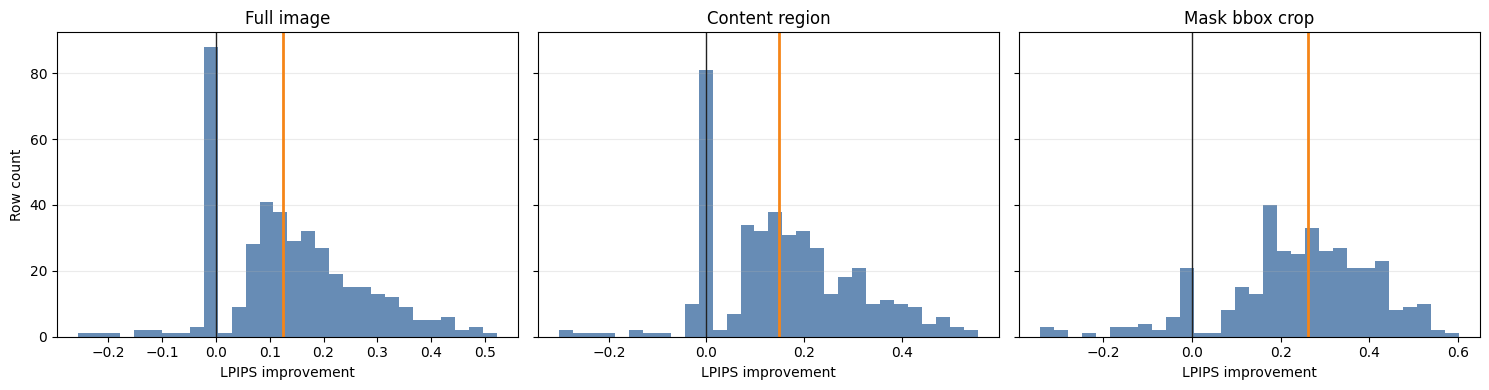

WindowsPath('D:/Masters/FH/Thesis/painting-restoration-eval/outputs/figures/17_lama_lpips_metrics/lpips_diagnostics_lama/lpips_improvement_distribution_by_region_lama.png')

In [29]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(REGION_ORDER),
    figsize=(5 * len(REGION_ORDER), 4),
    sharey=True,
)

if len(REGION_ORDER) == 1:
    axes = [axes]

for axis, evaluation_region in zip(axes, REGION_ORDER):
    region_values = lpips_plot_df.loc[
        lpips_plot_df["evaluation_region"].astype(str).eq(evaluation_region),
        "lpips_improvement",
    ].dropna()

    axis.hist(region_values, bins=30, color="#4C78A8", alpha=0.85)
    axis.axvline(0, color="#222222", linewidth=1)
    axis.axvline(region_values.median(), color="#F58518", linewidth=2)

    axis.set_title(REGION_LABELS.get(evaluation_region, evaluation_region))
    axis.set_xlabel("LPIPS improvement")
    axis.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Row count")

save_current_figure(
    "lpips_improvement_distribution_by_region_lama.png",
    "LPIPS improvement distribution by region",
    "Histogram of damaged-minus-restored LPIPS improvement for each evaluation region.",
)

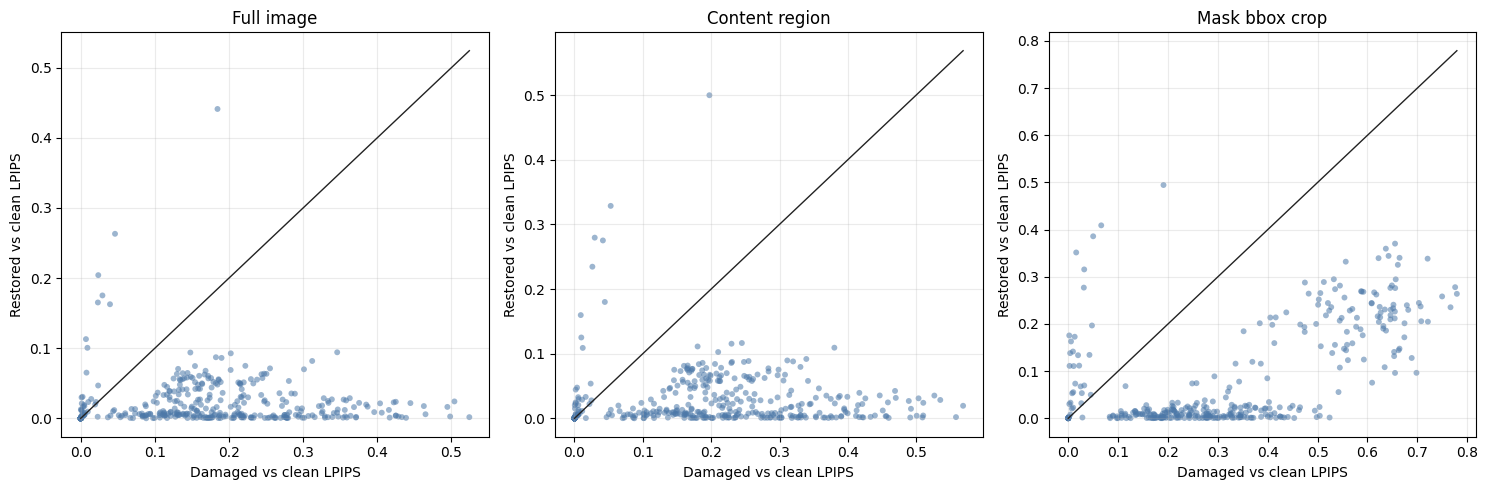

WindowsPath('D:/Masters/FH/Thesis/painting-restoration-eval/outputs/figures/17_lama_lpips_metrics/lpips_diagnostics_lama/damaged_vs_restored_lpips_scatter_lama.png')

In [30]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(REGION_ORDER),
    figsize=(5 * len(REGION_ORDER), 5),
    sharex=False,
    sharey=False,
)

if len(REGION_ORDER) == 1:
    axes = [axes]

for axis, evaluation_region in zip(axes, REGION_ORDER):
    region_df = lpips_plot_df.loc[
        lpips_plot_df["evaluation_region"].astype(str).eq(evaluation_region)
    ].copy()

    axis.scatter(
        region_df["damaged_lpips"],
        region_df["restored_lpips"],
        s=18,
        alpha=0.55,
        color="#4C78A8",
        edgecolors="none",
    )

    min_value = float(
        min(region_df["damaged_lpips"].min(), region_df["restored_lpips"].min())
    )
    max_value = float(
        max(region_df["damaged_lpips"].max(), region_df["restored_lpips"].max())
    )

    axis.plot([min_value, max_value], [min_value, max_value], color="#222222", linewidth=1)
    axis.set_title(REGION_LABELS.get(evaluation_region, evaluation_region))
    axis.set_xlabel("Damaged vs clean LPIPS")
    axis.set_ylabel("Restored vs clean LPIPS")
    axis.grid(alpha=0.25)

save_current_figure(
    "damaged_vs_restored_lpips_scatter_lama.png",
    "Damaged versus restored LPIPS",
    "Scatter plot where points below the diagonal indicate LPIPS improvement after restoration.",
)

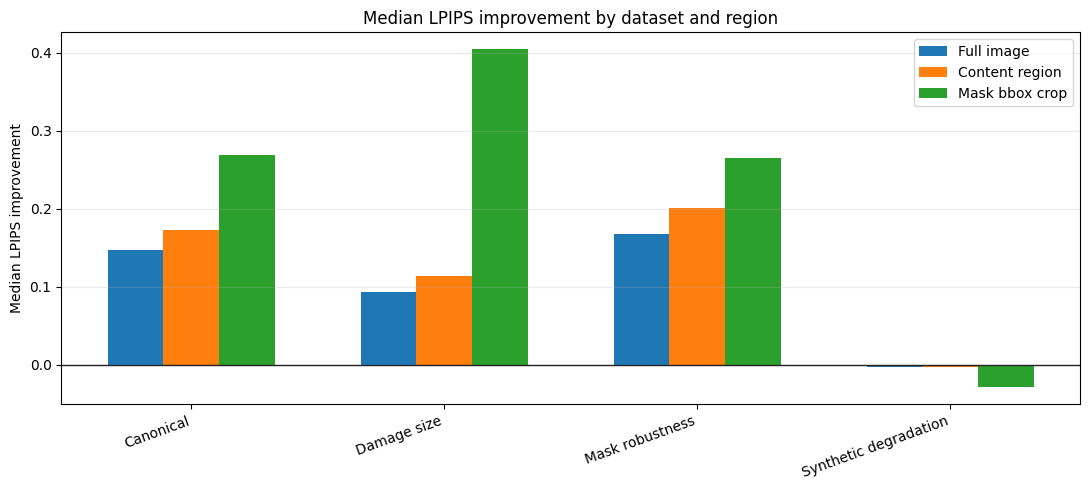

,dataset_name,evaluation_region,median_lpips_improvement,mean_lpips_improvement,improvement_rate,rows
0,canonical,full_image,0.147089,0.165311,0.8,250
1,canonical,content_region,0.173013,0.190697,0.8,250
2,canonical,mask_bbox_crop,0.268348,0.275095,1.0,200
3,damage_size,full_image,0.093615,0.106078,1.0,35
4,damage_size,content_region,0.114342,0.127586,1.0,35
5,damage_size,mask_bbox_crop,0.404265,0.412390,1.0,35
6,mask_robustness,full_image,0.167265,0.178445,1.0,75
7,mask_robustness,content_region,0.201040,0.206822,1.0,75
8,mask_robustness,mask_bbox_crop,0.264808,0.274119,1.0,75
9,synthetic_degradation,full_image,-0.002239,-0.030830,0.0,50


In [31]:
dataset_region_plot_df = (
    lpips_plot_df
    .groupby(["dataset_name", "evaluation_region"], observed=True, dropna=False)
    .agg(
        median_lpips_improvement=("lpips_improvement", "median"),
        mean_lpips_improvement=("lpips_improvement", "mean"),
        improvement_rate=("lpips_improvement", lambda values: float((values > 0).mean())),
        rows=("lpips_improvement", "count"),
    )
    .reset_index()
)

fig, axis = plt.subplots(figsize=(11, 5))

bar_width = 0.22
x_positions = np.arange(len(DATASET_ORDER))

for region_index, evaluation_region in enumerate(REGION_ORDER):
    region_summary_df = (
        dataset_region_plot_df.loc[
            dataset_region_plot_df["evaluation_region"].astype(str).eq(evaluation_region)
        ]
        .set_index("dataset_name")
        .reindex(DATASET_ORDER)
    )

    offsets = x_positions + (region_index - (len(REGION_ORDER) - 1) / 2) * bar_width

    axis.bar(
        offsets,
        region_summary_df["median_lpips_improvement"],
        width=bar_width,
        label=REGION_LABELS.get(evaluation_region, evaluation_region),
    )

axis.axhline(0, color="#222222", linewidth=1)
axis.set_xticks(x_positions)
axis.set_xticklabels(
    [DATASET_LABELS.get(dataset_name, dataset_name) for dataset_name in DATASET_ORDER],
    rotation=20,
    ha="right",
)
axis.set_ylabel("Median LPIPS improvement")
axis.set_title("Median LPIPS improvement by dataset and region")
axis.legend()
axis.grid(axis="y", alpha=0.25)

save_current_figure(
    "median_lpips_improvement_by_dataset_region_lama.png",
    "Median LPIPS improvement by dataset and region",
    "Grouped bar chart comparing median LPIPS improvement across experiment datasets and regions.",
)

display(dataset_region_plot_df.round(6))

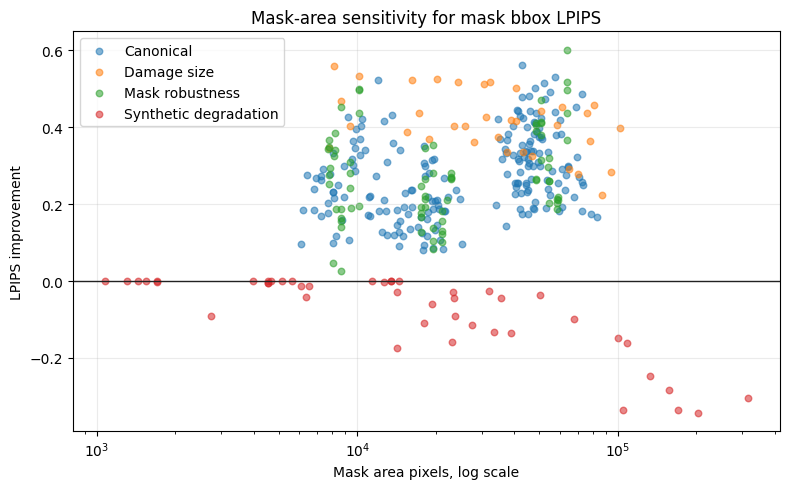

WindowsPath('D:/Masters/FH/Thesis/painting-restoration-eval/outputs/figures/17_lama_lpips_metrics/lpips_diagnostics_lama/mask_area_vs_lpips_improvement_lama.png')

In [32]:
mask_area_plot_df = lpips_plot_df.loc[
    lpips_plot_df["evaluation_region"].astype(str).eq("mask_bbox_crop")
].copy()

if "mask_area_pixels" not in mask_area_plot_df.columns:
    mask_area_plot_df["mask_area_pixels"] = np.nan

mask_area_plot_df = mask_area_plot_df.loc[
    mask_area_plot_df["mask_area_pixels"].notna()
    & mask_area_plot_df["mask_area_pixels"].gt(0)
].copy()

fig, axis = plt.subplots(figsize=(8, 5))

if mask_area_plot_df.empty:
    axis.text(
        0.5,
        0.5,
        "No positive mask_area_pixels available for mask-area diagnostic.",
        ha="center",
        va="center",
        transform=axis.transAxes,
    )
    axis.set_axis_off()
else:
    for dataset_name in DATASET_ORDER:
        dataset_df = mask_area_plot_df.loc[
            mask_area_plot_df["dataset_name"].astype(str).eq(dataset_name)
        ]

        if dataset_df.empty:
            continue

        axis.scatter(
            dataset_df["mask_area_pixels"],
            dataset_df["lpips_improvement"],
            s=22,
            alpha=0.55,
            label=DATASET_LABELS.get(dataset_name, dataset_name),
        )

    axis.axhline(0, color="#222222", linewidth=1)
    axis.set_xscale("log")
    axis.set_xlabel("Mask area pixels, log scale")
    axis.set_ylabel("LPIPS improvement")
    axis.set_title("Mask-area sensitivity for mask bbox LPIPS")
    axis.legend()
    axis.grid(alpha=0.25)

save_current_figure(
    "mask_area_vs_lpips_improvement_lama.png",
    "Mask area versus LPIPS improvement",
    "Scatter plot checking whether larger masks systematically change mask-bbox LPIPS improvement.",
)

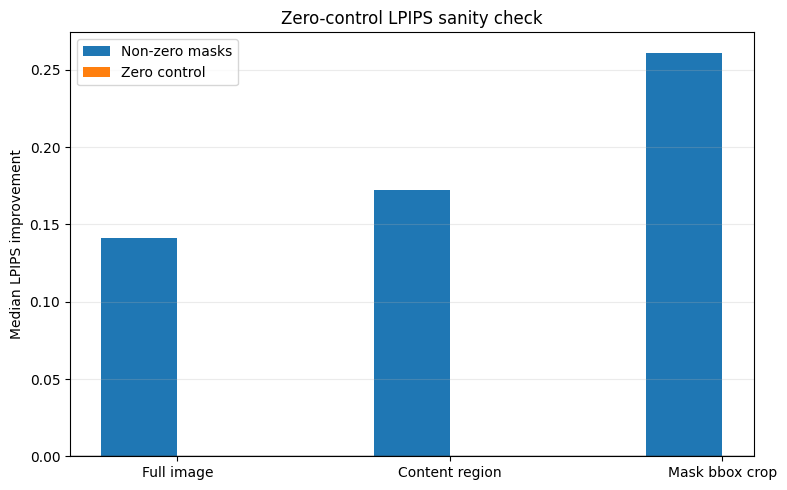

,is_zero_control,evaluation_region,median_lpips_improvement,mean_lpips_improvement,rows
0,False,full_image,0.141527,0.158006,360
1,False,content_region,0.172066,0.182092,360
2,False,mask_bbox_crop,0.261275,0.243354,355
3,True,full_image,0.000000,0.000000,50
4,True,content_region,0.000000,0.000000,50


In [33]:
zero_control_plot_df = (
    lpips_plot_df
    .groupby(["is_zero_control", "evaluation_region"], observed=True, dropna=False)
    .agg(
        median_lpips_improvement=("lpips_improvement", "median"),
        mean_lpips_improvement=("lpips_improvement", "mean"),
        rows=("lpips_improvement", "count"),
    )
    .reset_index()
)

fig, axis = plt.subplots(figsize=(8, 5))

zero_control_groups = [False, True]
bar_width = 0.28
x_positions = np.arange(len(REGION_ORDER))

for group_index, is_zero_control in enumerate(zero_control_groups):
    group_df = (
        zero_control_plot_df.loc[
            zero_control_plot_df["is_zero_control"].astype(bool).eq(is_zero_control)
        ]
        .set_index("evaluation_region")
        .reindex(REGION_ORDER)
    )

    offsets = x_positions + (group_index - 0.5) * bar_width

    axis.bar(
        offsets,
        group_df["median_lpips_improvement"],
        width=bar_width,
        label="Zero control" if is_zero_control else "Non-zero masks",
    )

axis.axhline(0, color="#222222", linewidth=1)
axis.set_xticks(x_positions)
axis.set_xticklabels([REGION_LABELS.get(region, region) for region in REGION_ORDER])
axis.set_ylabel("Median LPIPS improvement")
axis.set_title("Zero-control LPIPS sanity check")
axis.legend()
axis.grid(axis="y", alpha=0.25)

save_current_figure(
    "zero_control_lpips_sanity_lama.png",
    "Zero-control LPIPS sanity check",
    "Compares median LPIPS improvement for zero-control and non-zero mask cases.",
)

display(zero_control_plot_df.round(6))

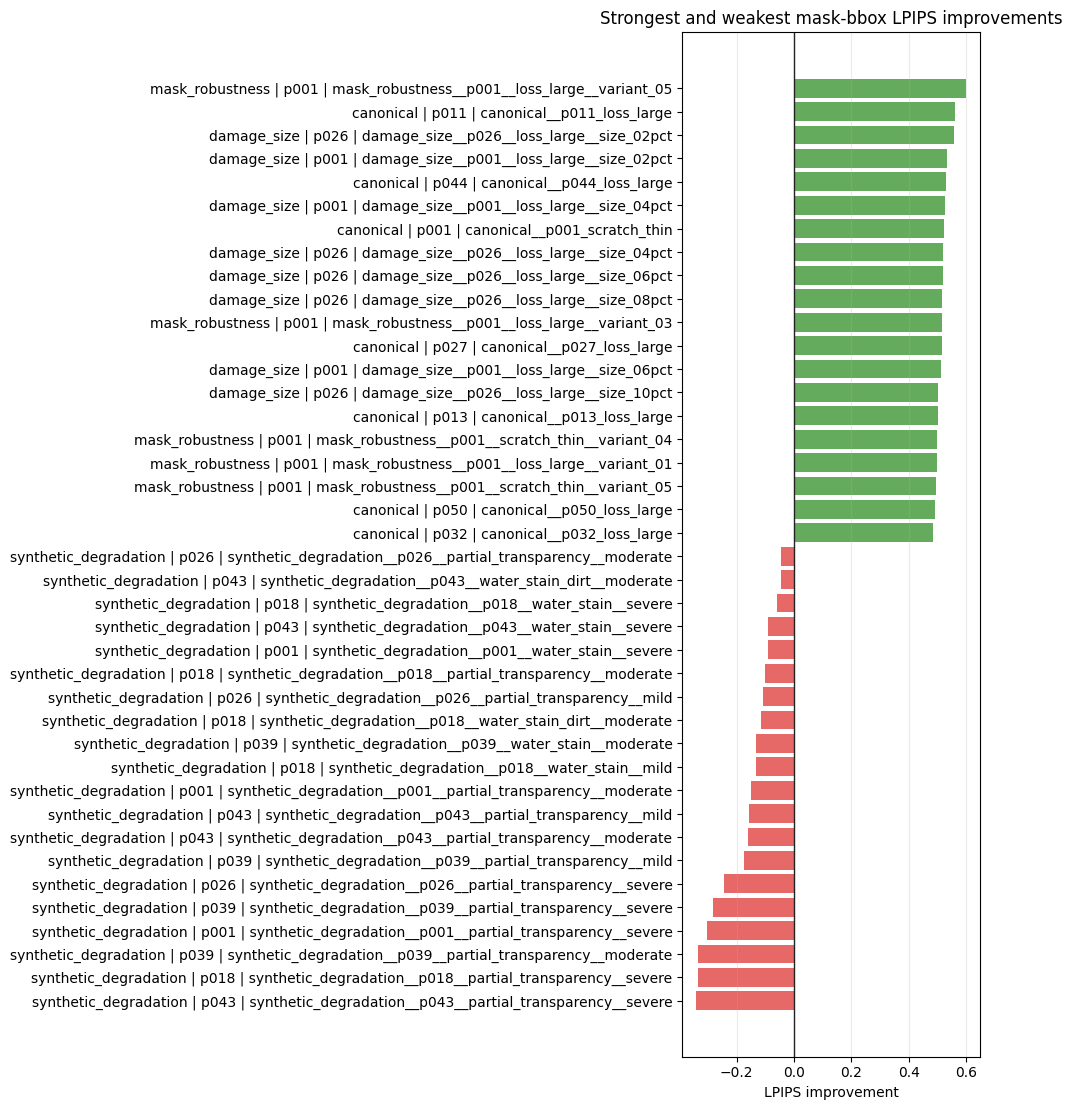

,rank_group,evaluation_region,dataset_name,case_id,painting_id,mask_type,damaged_lpips,restored_lpips,lpips_improvement
100,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p043__partial_transpare...,p043,NaN,0.066158,0.409115,-0.342957
101,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p018__partial_transpare...,p018,NaN,0.049984,0.385922,-0.335938
102,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p039__partial_transpare...,p039,NaN,0.015964,0.351621,-0.335657
103,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p001__partial_transpare...,p001,NaN,0.191041,0.494588,-0.303547
104,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p039__partial_transpare...,p039,NaN,0.032016,0.315672,-0.283656
105,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p026__partial_transpare...,p026,NaN,0.031275,0.277123,-0.245848
106,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p039__partial_transpare...,p039,NaN,0.002037,0.175717,-0.173680
107,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p043__partial_transpare...,p043,NaN,0.012950,0.172988,-0.160038
108,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p043__partial_transpare...,p043,NaN,0.005544,0.162985,-0.157441
109,weakest_improvement,mask_bbox_crop,synthetic_degradation,synthetic_degradation__p001__partial_transpare...,p001,NaN,0.047593,0.196815,-0.149222


In [34]:
rank_plot_region = "mask_bbox_crop"

if "lpips_ranked_by_region_compact_df" in globals():
    rank_plot_df = lpips_ranked_by_region_compact_df.loc[
        lpips_ranked_by_region_compact_df["evaluation_region"].astype(str).eq(rank_plot_region)
    ].copy()
elif LPIPS_RANKED_BY_REGION_OUTPUT_PATH.is_file():
    rank_plot_df = pd.read_csv(LPIPS_RANKED_BY_REGION_OUTPUT_PATH)
    rank_plot_df = rank_plot_df.loc[
        rank_plot_df["evaluation_region"].astype(str).eq(rank_plot_region)
    ].copy()
else:
    strongest_df, weakest_df = rank_lpips_cases(
        lpips_plot_df,
        evaluation_region=rank_plot_region,
        top_n=10,
    )

    strongest_df = strongest_df.assign(rank_group="strongest_improvement")
    weakest_df = weakest_df.assign(rank_group="weakest_improvement")
    rank_plot_df = pd.concat([strongest_df, weakest_df], ignore_index=True)

rank_plot_df["lpips_improvement"] = pd.to_numeric(
    rank_plot_df["lpips_improvement"],
    errors="coerce",
)

plot_rank_df = (
    rank_plot_df
    .dropna(subset=["lpips_improvement"])
    .copy()
)

plot_rank_df["plot_label"] = (
    plot_rank_df["dataset_name"].astype(str)
    + " | "
    + plot_rank_df["painting_id"].astype(str)
    + " | "
    + plot_rank_df["case_id"].astype(str)
)

plot_rank_df = plot_rank_df.sort_values("lpips_improvement", ascending=True, kind="stable")

fig_height = max(6, 0.28 * len(plot_rank_df))
fig, axis = plt.subplots(figsize=(10, fig_height))

colors = np.where(plot_rank_df["lpips_improvement"].ge(0), "#54A24B", "#E45756")

axis.barh(
    plot_rank_df["plot_label"],
    plot_rank_df["lpips_improvement"],
    color=colors,
    alpha=0.9,
)

axis.axvline(0, color="#222222", linewidth=1)
axis.set_xlabel("LPIPS improvement")
axis.set_title("Strongest and weakest mask-bbox LPIPS improvements")
axis.grid(axis="x", alpha=0.25)

save_current_figure(
    "strongest_weakest_mask_bbox_lpips_improvements_lama.png",
    "Strongest and weakest mask-bbox LPIPS improvements",
    "Horizontal bar chart of top-ranked positive and negative mask-bbox LPIPS improvement cases.",
)

display(
    plot_rank_df[
        [
            column
            for column in [
                "rank_group",
                "evaluation_region",
                "dataset_name",
                "case_id",
                "painting_id",
                "mask_type",
                "damaged_lpips",
                "restored_lpips",
                "lpips_improvement",
            ]
            if column in plot_rank_df.columns
        ]
    ]
)

In [35]:
lpips_diagnostic_figure_manifest_df = pd.DataFrame(figure_records)

lpips_diagnostic_figure_manifest_df.to_csv(
    LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH,
    index=False,
)

figure_save_checks_df = pd.DataFrame(
    [
        build_check(
            "diagnostic_figures_created",
            int(lpips_diagnostic_figure_manifest_df["exists"].sum()),
            len(lpips_diagnostic_figure_manifest_df),
            bool(lpips_diagnostic_figure_manifest_df["exists"].all()),
        ),
        build_check(
            "figure_manifest_saved",
            LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH.is_file(),
            True,
            LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH.is_file(),
        ),
        build_check(
            "figure_manifest_nonempty",
            len(lpips_diagnostic_figure_manifest_df),
            "> 0",
            len(lpips_diagnostic_figure_manifest_df) > 0,
        ),
    ]
)

display(lpips_diagnostic_figure_manifest_df)
display(figure_save_checks_df)

figure_save_checks_df.to_csv(LPIPS_BATCH6_VALIDATION_OUTPUT_PATH, index=False)

if not figure_save_checks_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 6 diagnostic figure save validation failed.")

if LPIPS_STAGE_MANIFEST_JSON_PATH.is_file():
    with open(LPIPS_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
        lpips_stage_manifest = json.load(manifest_file)
else:
    lpips_stage_manifest = {}

lpips_stage_manifest["batch_6"] = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "diagnostic_plots_and_figures",
    "outputs": {
        "figure_directory": project_relative_path(LPIPS_DIAGNOSTIC_FIGURES_DIR),
        "figure_manifest": project_relative_path(LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH),
        "batch6_validation": project_relative_path(LPIPS_BATCH6_VALIDATION_OUTPUT_PATH),
    },
    "figures": lpips_diagnostic_figure_manifest_df[
        ["figure_id", "title", "path_project_relative"]
    ].to_dict(orient="records"),
    "validation_passed": bool(figure_save_checks_df["passed"].astype(bool).all()),
}

with open(LPIPS_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(lpips_stage_manifest, manifest_file, indent=2, default=json_safe)

print("Batch 6 complete.")
print("Diagnostic figures:", project_relative_path(LPIPS_DIAGNOSTIC_FIGURES_DIR))
print("Figure manifest:", project_relative_path(LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH))

,figure_id,title,description,path,path_project_relative,exists,size_bytes
0,lpips_improvement_distribution_by_region_lama,LPIPS improvement distribution by region,Histogram of damaged-minus-restored LPIPS impr...,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\figures\17_lama_lpips_metrics\lpips_di...,True,36187
1,damaged_vs_restored_lpips_scatter_lama,Damaged versus restored LPIPS,Scatter plot where points below the diagonal i...,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\figures\17_lama_lpips_metrics\lpips_di...,True,226440
2,median_lpips_improvement_by_dataset_region_lama,Median LPIPS improvement by dataset and region,Grouped bar chart comparing median LPIPS impro...,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\figures\17_lama_lpips_metrics\lpips_di...,True,70058
3,mask_area_vs_lpips_improvement_lama,Mask area versus LPIPS improvement,Scatter plot checking whether larger masks sys...,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\figures\17_lama_lpips_metrics\lpips_di...,True,112718
4,zero_control_lpips_sanity_lama,Zero-control LPIPS sanity check,Compares median LPIPS improvement for zero-con...,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\figures\17_lama_lpips_metrics\lpips_di...,True,41725
5,strongest_weakest_mask_bbox_lpips_improvements...,Strongest and weakest mask-bbox LPIPS improvem...,Horizontal bar chart of top-ranked positive an...,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\figures\17_lama_lpips_metrics\lpips_di...,True,539657


,check,observed,expected,passed,severity
0,diagnostic_figures_created,6,6,True,error
1,figure_manifest_saved,True,True,True,error
2,figure_manifest_nonempty,6,> 0,True,error


Batch 6 complete.
Diagnostic figures: outputs\figures\17_lama_lpips_metrics\lpips_diagnostics_lama
Figure manifest: outputs\figures\17_lama_lpips_metrics\lpips_diagnostics_lama\lpips_diagnostic_figure_manifest_lama.csv


In [36]:
LPIPS_FINAL_VALIDATION_OUTPUT_PATH = (
    VALIDATION_DIR / "lpips_final_validation_lama.csv"
)

LPIPS_HANDOFF_MANIFEST_JSON_PATH = (
    METRICS_DIR / "lpips_handoff_manifest_lama.json"
)

# Recreate Batch 5/6 path constants if this notebook was resumed in a fresh kernel.
LPIPS_COMPACT_METRICS_OUTPUT_PATH = METRICS_DIR / "lpips_metrics_lama_compact.csv"
LPIPS_DATASET_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_dataset_region_lama.csv"
LPIPS_MASK_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_mask_region_lama.csv"
LPIPS_CATEGORY_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_by_category_region_lama.csv"
LPIPS_ZERO_CONTROL_SUMMARY_OUTPUT_PATH = METRICS_DIR / "lpips_summary_zero_control_lama.csv"
LPIPS_RANKED_BY_REGION_OUTPUT_PATH = METRICS_DIR / "lpips_ranked_cases_by_region_lama.csv"
LPIPS_BATCH5_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "lpips_batch5_validation_lama.csv"

LPIPS_DIAGNOSTIC_FIGURES_DIR = FIGURES_DIR / "lpips_diagnostics_lama"
LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH = (
    LPIPS_DIAGNOSTIC_FIGURES_DIR / "lpips_diagnostic_figure_manifest_lama.csv"
)
LPIPS_BATCH6_VALIDATION_OUTPUT_PATH = (
    VALIDATION_DIR / "lpips_batch6_figure_validation_lama.csv"
)


def file_audit_record(artifact: str, path: Path, required: bool = True) -> dict:
    path = Path(path)

    return {
        "artifact": artifact,
        "path": path,
        "path_project_relative": project_relative_path(path),
        "required": bool(required),
        "exists": path.is_file(),
        "size_bytes": path.stat().st_size if path.is_file() else 0,
    }


def read_csv_if_exists(path: Path, artifact_name: str) -> pd.DataFrame:
    if not Path(path).is_file():
        raise RuntimeError(f"Missing required artifact: {artifact_name} -> {project_relative_path(path)}")

    return pd.read_csv(path)


def json_safe_final(value):
    if "json_safe" in globals():
        return json_safe(value)

    if isinstance(value, Path):
        return project_relative_path(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()

    return value

In [37]:
required_artifact_paths = {
    "raw_lpips_metrics": LPIPS_METRICS_OUTPUT_PATH,
    "compact_lpips_metrics": LPIPS_COMPACT_METRICS_OUTPUT_PATH,
    "dataset_region_summary": LPIPS_DATASET_REGION_SUMMARY_OUTPUT_PATH,
    "mask_region_summary": LPIPS_MASK_REGION_SUMMARY_OUTPUT_PATH,
    "category_region_summary": LPIPS_CATEGORY_REGION_SUMMARY_OUTPUT_PATH,
    "zero_control_summary": LPIPS_ZERO_CONTROL_SUMMARY_OUTPUT_PATH,
    "ranked_by_region": LPIPS_RANKED_BY_REGION_OUTPUT_PATH,
    "batch5_validation": LPIPS_BATCH5_VALIDATION_OUTPUT_PATH,
    "diagnostic_figure_manifest": LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH,
    "batch6_validation": LPIPS_BATCH6_VALIDATION_OUTPUT_PATH,
    "stage_manifest": LPIPS_STAGE_MANIFEST_JSON_PATH,
}

artifact_audit_df = pd.DataFrame(
    [
        file_audit_record(artifact, path, required=True)
        for artifact, path in required_artifact_paths.items()
    ]
)

display(artifact_audit_df)

missing_required_artifacts = artifact_audit_df.loc[
    artifact_audit_df["required"].astype(bool)
    & ~artifact_audit_df["exists"].astype(bool)
]

if not missing_required_artifacts.empty:
    display(missing_required_artifacts)
    raise RuntimeError("Batch 7 failed because required handoff artifacts are missing.")

,artifact,path,path_project_relative,required,exists,size_bytes
0,raw_lpips_metrics,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_metrics_lama.csv,True,True,856763
1,compact_lpips_metrics,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_metrics_lama_compact.csv,True,True,526051
2,dataset_region_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_by_dataset_regio...,True,True,1449
3,mask_region_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_by_mask_region_l...,True,True,2635
4,category_region_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_by_category_regi...,True,True,1909
5,zero_control_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_summary_zero_control_lam...,True,True,644
6,ranked_by_region,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_ranked_cases_by_region_l...,True,True,43432
7,batch5_validation,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\validation\lpips_batch5_validation_lam...,True,True,853
8,diagnostic_figure_manifest,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\figures\17_lama_lpips_metrics\lpips_di...,True,True,2731
9,batch6_validation,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\validation\lpips_batch6_figure_validat...,True,True,171


In [38]:
lpips_raw_final_df = read_csv_if_exists(
    LPIPS_METRICS_OUTPUT_PATH,
    "raw_lpips_metrics",
)

lpips_compact_final_df = read_csv_if_exists(
    LPIPS_COMPACT_METRICS_OUTPUT_PATH,
    "compact_lpips_metrics",
)

lpips_dataset_region_final_df = read_csv_if_exists(
    LPIPS_DATASET_REGION_SUMMARY_OUTPUT_PATH,
    "dataset_region_summary",
)

lpips_mask_region_final_df = read_csv_if_exists(
    LPIPS_MASK_REGION_SUMMARY_OUTPUT_PATH,
    "mask_region_summary",
)

lpips_category_region_final_df = read_csv_if_exists(
    LPIPS_CATEGORY_REGION_SUMMARY_OUTPUT_PATH,
    "category_region_summary",
)

lpips_zero_control_final_df = read_csv_if_exists(
    LPIPS_ZERO_CONTROL_SUMMARY_OUTPUT_PATH,
    "zero_control_summary",
)

lpips_ranked_region_final_df = read_csv_if_exists(
    LPIPS_RANKED_BY_REGION_OUTPUT_PATH,
    "ranked_by_region",
)

batch5_validation_final_df = read_csv_if_exists(
    LPIPS_BATCH5_VALIDATION_OUTPUT_PATH,
    "batch5_validation",
)

batch6_validation_final_df = read_csv_if_exists(
    LPIPS_BATCH6_VALIDATION_OUTPUT_PATH,
    "batch6_validation",
)

figure_manifest_final_df = read_csv_if_exists(
    LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH,
    "diagnostic_figure_manifest",
)

raw_region_counts_final = (
    lpips_raw_final_df["evaluation_region"]
    .value_counts()
    .to_dict()
)

expected_region_counts_final = {
    key: int(value)
    for key, value in lpips_expected_region_counts.items()
}

region_counts_match = raw_region_counts_final == expected_region_counts_final

raw_ok_df = lpips_raw_final_df.loc[
    lpips_raw_final_df["status"].astype(str).eq("ok")
].copy()

required_raw_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "evaluation_region",
    "status",
    "damaged_lpips",
    "restored_lpips",
    "lpips_improvement",
]

missing_raw_columns = [
    column
    for column in required_raw_columns
    if column not in lpips_raw_final_df.columns
]

finite_raw_metric_values = True

if not missing_raw_columns:
    metric_array = (
        raw_ok_df[["damaged_lpips", "restored_lpips", "lpips_improvement"]]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    )
    finite_raw_metric_values = bool(np.isfinite(metric_array).all())

batch5_passed = bool(batch5_validation_final_df["passed"].astype(bool).all())
batch6_passed = bool(batch6_validation_final_df["passed"].astype(bool).all())

figure_manifest_paths_exist = bool(
    figure_manifest_final_df["exists"].astype(bool).all()
)

handoff_table_validation_df = pd.DataFrame(
    [
        build_check(
            "raw_lpips_row_count",
            len(lpips_raw_final_df),
            int(lpips_expected_total_rows),
            len(lpips_raw_final_df) == int(lpips_expected_total_rows),
        ),
        build_check(
            "raw_lpips_region_counts",
            raw_region_counts_final,
            expected_region_counts_final,
            region_counts_match,
        ),
        build_check(
            "raw_required_columns_present",
            missing_raw_columns,
            [],
            len(missing_raw_columns) == 0,
        ),
        build_check(
            "raw_ok_metric_values_finite",
            finite_raw_metric_values,
            True,
            finite_raw_metric_values,
        ),
        build_check(
            "compact_metrics_nonempty",
            len(lpips_compact_final_df),
            "> 0",
            len(lpips_compact_final_df) > 0,
        ),
        build_check(
            "summary_tables_nonempty",
            {
                "dataset_region": len(lpips_dataset_region_final_df),
                "mask_region": len(lpips_mask_region_final_df),
                "category_region": len(lpips_category_region_final_df),
                "zero_control": len(lpips_zero_control_final_df),
            },
            "all > 0",
            all(
                len(df) > 0
                for df in [
                    lpips_dataset_region_final_df,
                    lpips_mask_region_final_df,
                    lpips_category_region_final_df,
                    lpips_zero_control_final_df,
                ]
            ),
        ),
        build_check(
            "ranked_cases_nonempty",
            len(lpips_ranked_region_final_df),
            "> 0",
            len(lpips_ranked_region_final_df) > 0,
        ),
        build_check(
            "batch5_validation_passed",
            batch5_passed,
            True,
            batch5_passed,
        ),
        build_check(
            "batch6_validation_passed",
            batch6_passed,
            True,
            batch6_passed,
        ),
        build_check(
            "diagnostic_figures_exist",
            figure_manifest_paths_exist,
            True,
            figure_manifest_paths_exist,
        ),
    ]
)

display(handoff_table_validation_df)

if not handoff_table_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 7 handoff table validation failed.")

,check,observed,expected,passed,severity
0,raw_lpips_row_count,1175,1175,True,error
1,raw_lpips_region_counts,"{'full_image': 410, 'content_region': 410, 'ma...","{'full_image': 410, 'content_region': 410, 'ma...",True,error
2,raw_required_columns_present,[],[],True,error
3,raw_ok_metric_values_finite,True,True,True,error
4,compact_metrics_nonempty,1175,> 0,True,error
5,summary_tables_nonempty,"{'dataset_region': 12, 'mask_region': 23, 'cat...",all > 0,True,error
6,ranked_cases_nonempty,120,> 0,True,error
7,batch5_validation_passed,True,True,True,error
8,batch6_validation_passed,True,True,True,error
9,diagnostic_figures_exist,True,True,True,error


In [39]:
with open(LPIPS_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
    lpips_stage_manifest_final = json.load(manifest_file)

expected_stage_batches = ["batch_5", "batch_6"]

missing_stage_batches = [
    batch_name
    for batch_name in expected_stage_batches
    if batch_name not in lpips_stage_manifest_final
]

failed_stage_batches = [
    batch_name
    for batch_name in expected_stage_batches
    if (
        batch_name in lpips_stage_manifest_final
        and not bool(lpips_stage_manifest_final[batch_name].get("validation_passed", False))
    )
]

stage_manifest_validation_df = pd.DataFrame(
    [
        build_check(
            "stage_manifest_exists",
            LPIPS_STAGE_MANIFEST_JSON_PATH.is_file(),
            True,
            LPIPS_STAGE_MANIFEST_JSON_PATH.is_file(),
        ),
        build_check(
            "stage_manifest_expected_batches_present",
            missing_stage_batches,
            [],
            len(missing_stage_batches) == 0,
        ),
        build_check(
            "stage_manifest_batches_passed",
            failed_stage_batches,
            [],
            len(failed_stage_batches) == 0,
        ),
    ]
)

display(stage_manifest_validation_df)

if not stage_manifest_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 7 stage manifest validation failed.")

,check,observed,expected,passed,severity
0,stage_manifest_exists,True,True,True,error
1,stage_manifest_expected_batches_present,[],[],True,error
2,stage_manifest_batches_passed,[],[],True,error


In [40]:
artifact_validation_df = artifact_audit_df.assign(
    check_name=lambda df: "artifact_exists__" + df["artifact"].astype(str),
    observed=lambda df: df["exists"].astype(bool),
    expected=True,
    passed=lambda df: df["exists"].astype(bool),
    issue=lambda df: np.where(df["exists"].astype(bool), "", "missing_required_artifact"),
)

artifact_validation_df = artifact_validation_df[
    [
        "check_name",
        "observed",
        "expected",
        "passed",
        "issue",
        "artifact",
        "path_project_relative",
        "size_bytes",
    ]
]

handoff_table_validation_export_df = handoff_table_validation_df.assign(
    artifact="handoff_tables",
    path_project_relative="",
    size_bytes=np.nan,
)

stage_manifest_validation_export_df = stage_manifest_validation_df.assign(
    artifact="stage_manifest",
    path_project_relative=project_relative_path(LPIPS_STAGE_MANIFEST_JSON_PATH),
    size_bytes=LPIPS_STAGE_MANIFEST_JSON_PATH.stat().st_size,
)

final_validation_df = pd.concat(
    [
        artifact_validation_df,
        handoff_table_validation_export_df,
        stage_manifest_validation_export_df,
    ],
    ignore_index=True,
    sort=False,
)

final_validation_df.to_csv(LPIPS_FINAL_VALIDATION_OUTPUT_PATH, index=False)

handoff_manifest = {
    "notebook_name": NOTEBOOK_NAME,
    "model_name": MODEL_NAME,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "handoff_status": "ready_for_downstream_analysis",
    "validation": {
        "final_validation_csv": project_relative_path(LPIPS_FINAL_VALIDATION_OUTPUT_PATH),
        "checks_total": int(len(final_validation_df)),
        "checks_passed": int(final_validation_df["passed"].astype(bool).sum()),
        "all_checks_passed": bool(final_validation_df["passed"].astype(bool).all()),
    },
    "lpips_contract": {
        "schema_version": LPIPS_METRIC_SCHEMA_VERSION,
        "lpips_net": LPIPS_NET,
        "expected_rows": int(lpips_expected_total_rows),
        "actual_rows": int(len(lpips_raw_final_df)),
        "expected_region_counts": expected_region_counts_final,
        "actual_region_counts": {
            key: int(value)
            for key, value in raw_region_counts_final.items()
        },
    },
    "core_outputs": {
        "raw_lpips_metrics": project_relative_path(LPIPS_METRICS_OUTPUT_PATH),
        "compact_lpips_metrics": project_relative_path(LPIPS_COMPACT_METRICS_OUTPUT_PATH),
        "dataset_region_summary": project_relative_path(LPIPS_DATASET_REGION_SUMMARY_OUTPUT_PATH),
        "mask_region_summary": project_relative_path(LPIPS_MASK_REGION_SUMMARY_OUTPUT_PATH),
        "category_region_summary": project_relative_path(LPIPS_CATEGORY_REGION_SUMMARY_OUTPUT_PATH),
        "zero_control_summary": project_relative_path(LPIPS_ZERO_CONTROL_SUMMARY_OUTPUT_PATH),
        "ranked_by_region": project_relative_path(LPIPS_RANKED_BY_REGION_OUTPUT_PATH),
    },
    "diagnostics": {
        "figure_directory": project_relative_path(LPIPS_DIAGNOSTIC_FIGURES_DIR),
        "figure_manifest": project_relative_path(LPIPS_DIAGNOSTIC_FIGURE_MANIFEST_PATH),
        "figure_count": int(len(figure_manifest_final_df)),
    },
    "upstream_validation_outputs": {
        "batch5_validation": project_relative_path(LPIPS_BATCH5_VALIDATION_OUTPUT_PATH),
        "batch6_validation": project_relative_path(LPIPS_BATCH6_VALIDATION_OUTPUT_PATH),
        "stage_manifest": project_relative_path(LPIPS_STAGE_MANIFEST_JSON_PATH),
    },
    "table_shapes": {
        "raw_lpips_metrics": {
            "rows": int(len(lpips_raw_final_df)),
            "columns": int(len(lpips_raw_final_df.columns)),
        },
        "compact_lpips_metrics": {
            "rows": int(len(lpips_compact_final_df)),
            "columns": int(len(lpips_compact_final_df.columns)),
        },
        "ranked_by_region": {
            "rows": int(len(lpips_ranked_region_final_df)),
            "columns": int(len(lpips_ranked_region_final_df.columns)),
        },
    },
}

if not handoff_manifest["validation"]["all_checks_passed"]:
    handoff_manifest["handoff_status"] = "blocked"

with open(LPIPS_HANDOFF_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(handoff_manifest, manifest_file, indent=2, default=json_safe_final)

display(final_validation_df)
display(
    pd.DataFrame(
        [
            file_audit_record(
                "final_validation_csv",
                LPIPS_FINAL_VALIDATION_OUTPUT_PATH,
                required=True,
            ),
            file_audit_record(
                "handoff_manifest_json",
                LPIPS_HANDOFF_MANIFEST_JSON_PATH,
                required=True,
            ),
        ]
    )
)

if not final_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 7 final validation failed.")

print("Batch 7 complete.")
print("Final validation:", project_relative_path(LPIPS_FINAL_VALIDATION_OUTPUT_PATH))
print("Handoff manifest:", project_relative_path(LPIPS_HANDOFF_MANIFEST_JSON_PATH))
print("Handoff status:", handoff_manifest["handoff_status"])

,check_name,observed,expected,passed,issue,artifact,path_project_relative,size_bytes,check,severity
0,artifact_exists__raw_lpips_metrics,True,True,True,,raw_lpips_metrics,outputs\metrics\lpips_metrics_lama.csv,856763.0,NaN,NaN
1,artifact_exists__compact_lpips_metrics,True,True,True,,compact_lpips_metrics,outputs\metrics\lpips_metrics_lama_compact.csv,526051.0,NaN,NaN
2,artifact_exists__dataset_region_summary,True,True,True,,dataset_region_summary,outputs\metrics\lpips_summary_by_dataset_regio...,1449.0,NaN,NaN
3,artifact_exists__mask_region_summary,True,True,True,,mask_region_summary,outputs\metrics\lpips_summary_by_mask_region_l...,2635.0,NaN,NaN
4,artifact_exists__category_region_summary,True,True,True,,category_region_summary,outputs\metrics\lpips_summary_by_category_regi...,1909.0,NaN,NaN
5,artifact_exists__zero_control_summary,True,True,True,,zero_control_summary,outputs\metrics\lpips_summary_zero_control_lam...,644.0,NaN,NaN
6,artifact_exists__ranked_by_region,True,True,True,,ranked_by_region,outputs\metrics\lpips_ranked_cases_by_region_l...,43432.0,NaN,NaN
7,artifact_exists__batch5_validation,True,True,True,,batch5_validation,outputs\validation\lpips_batch5_validation_lam...,853.0,NaN,NaN
8,artifact_exists__diagnostic_figure_manifest,True,True,True,,diagnostic_figure_manifest,outputs\figures\17_lama_lpips_metrics\lpips_di...,2731.0,NaN,NaN
9,artifact_exists__batch6_validation,True,True,True,,batch6_validation,outputs\validation\lpips_batch6_figure_validat...,171.0,NaN,NaN


,artifact,path,path_project_relative,required,exists,size_bytes
0,final_validation_csv,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\validation\lpips_final_validation_lama...,True,True,2894
1,handoff_manifest_json,D:\Masters\FH\Thesis\painting-restoration-eval...,outputs\metrics\lpips_handoff_manifest_lama.json,True,True,2222


Batch 7 complete.
Final validation: outputs\validation\lpips_final_validation_lama.csv
Handoff manifest: outputs\metrics\lpips_handoff_manifest_lama.json
Handoff status: ready_for_downstream_analysis
